In [8]:
# this path append is for binder only
import sys
sys.path.append("../../")

#spectrome modules
from spectrome.utils import functions, path
from spectrome.brain import Brain

from spectrome.forward import ntf_local_stimulus as nt_stim
from spectrome.forward import ntf_local as nt_nostim
from spectrome.forward import ntf_local_stimulus as nt_stim

#generic modules
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
import pickle as pkl
from scipy import stats
from scipy.io import loadmat
from scipy.stats import pearsonr, spearmanr
from scipy.io import savemat


# from fooof import FOOOF
from fooof.plts.annotate import plot_annotated_model

from statsmodels.stats.multicomp import MultiComparison
import statsmodels.stats
import statsmodels.api as sm
from statsmodels.stats import weightstats
from statsmodels.stats.multitest import fdrcorrection
import pingouin as pg
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import mannwhitneyu

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import fdrcorrection

plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

In [9]:
##all the sessions data of MEG
data1=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess1.mat")
data2=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess2.mat")
data3=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess3.mat")
data4=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess4.mat")


##all the sessions mi 
sess1_mi_avg=data1['Avg_MI_MEG_DK']
sess2_mi_avg=data2['Avg_MI_MEG_DK']
sess3_mi_avg=data3['Avg_MI_MEG_DK']
sess4_mi_avg=data4['Avg_MI_EEG_DK']

##all the sessions resting state
sess1_rest_avg=data1['Avg_RS1_MEG_DK']
sess2_rest_avg=data2['Avg_RS1_MEG_DK']
sess3_rest_avg=data3['Avg_RS1_MEG_DK']
sess4_rest_avg=data4['Avg_RS1_EEG_DK']

##all the sessions baseline
sess1_base_avg=data1['Avg_Baseline_MEG_DK']
sess2_base_avg=data2['Avg_Baseline_MEG_DK']
sess3_base_avg=data3['Avg_Baseline_MEG_DK']
sess4_base_avg=data4['Avg_Baseline_EEG_DK']

In [10]:
## Load all the regions
df=pd.read_excel('../../ListROIs_DK.xlsx')
##targeted frequency range
fvec = np.squeeze(data1["Freqs"])[3:30]

In [11]:
all_regions=[]
all_regions_idx=[]
for i,r in df.iterrows():
    all_regions_idx.append(i)
    all_regions.append(r['ROI'])

In [12]:
##modeled data-MEG
x_mi_all={}
x_base_all={}
x_rest_all={}

for num in range(1, 5):
    x_mi_all[num]=np.zeros((68, 10, 19))
    x_base_all[num]=np.zeros((68, 10, 19))
    x_rest_all[num]=np.zeros((68, 10, 19))
    
    for i in range(19):
        mi_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/mi_allsubs_f/mi_nostim_mse_db_fvec330_{i}.p'
        with open(mi_fname, 'rb') as f:
            x_mi_all[num][:,:,i]=np.array(pkl.load(f))

        base_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/baseline_allsubs_f/baseline_nostim_mse_db_fvec330_{i}.p'
        with open(base_fname, 'rb') as f:
            x_base_all[num][:,:,i] = np.array(pkl.load(f))

        rest_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/rs1_allsubs_f0/rs1_nostim_mse_db_fvec330_{i}.p'
        with open(rest_fname, 'rb') as f:
            x_rest_all[num][:,:,i]=np.array(pkl.load(f))
  

## Pearson correlation between modeled and actual in MI and RS

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


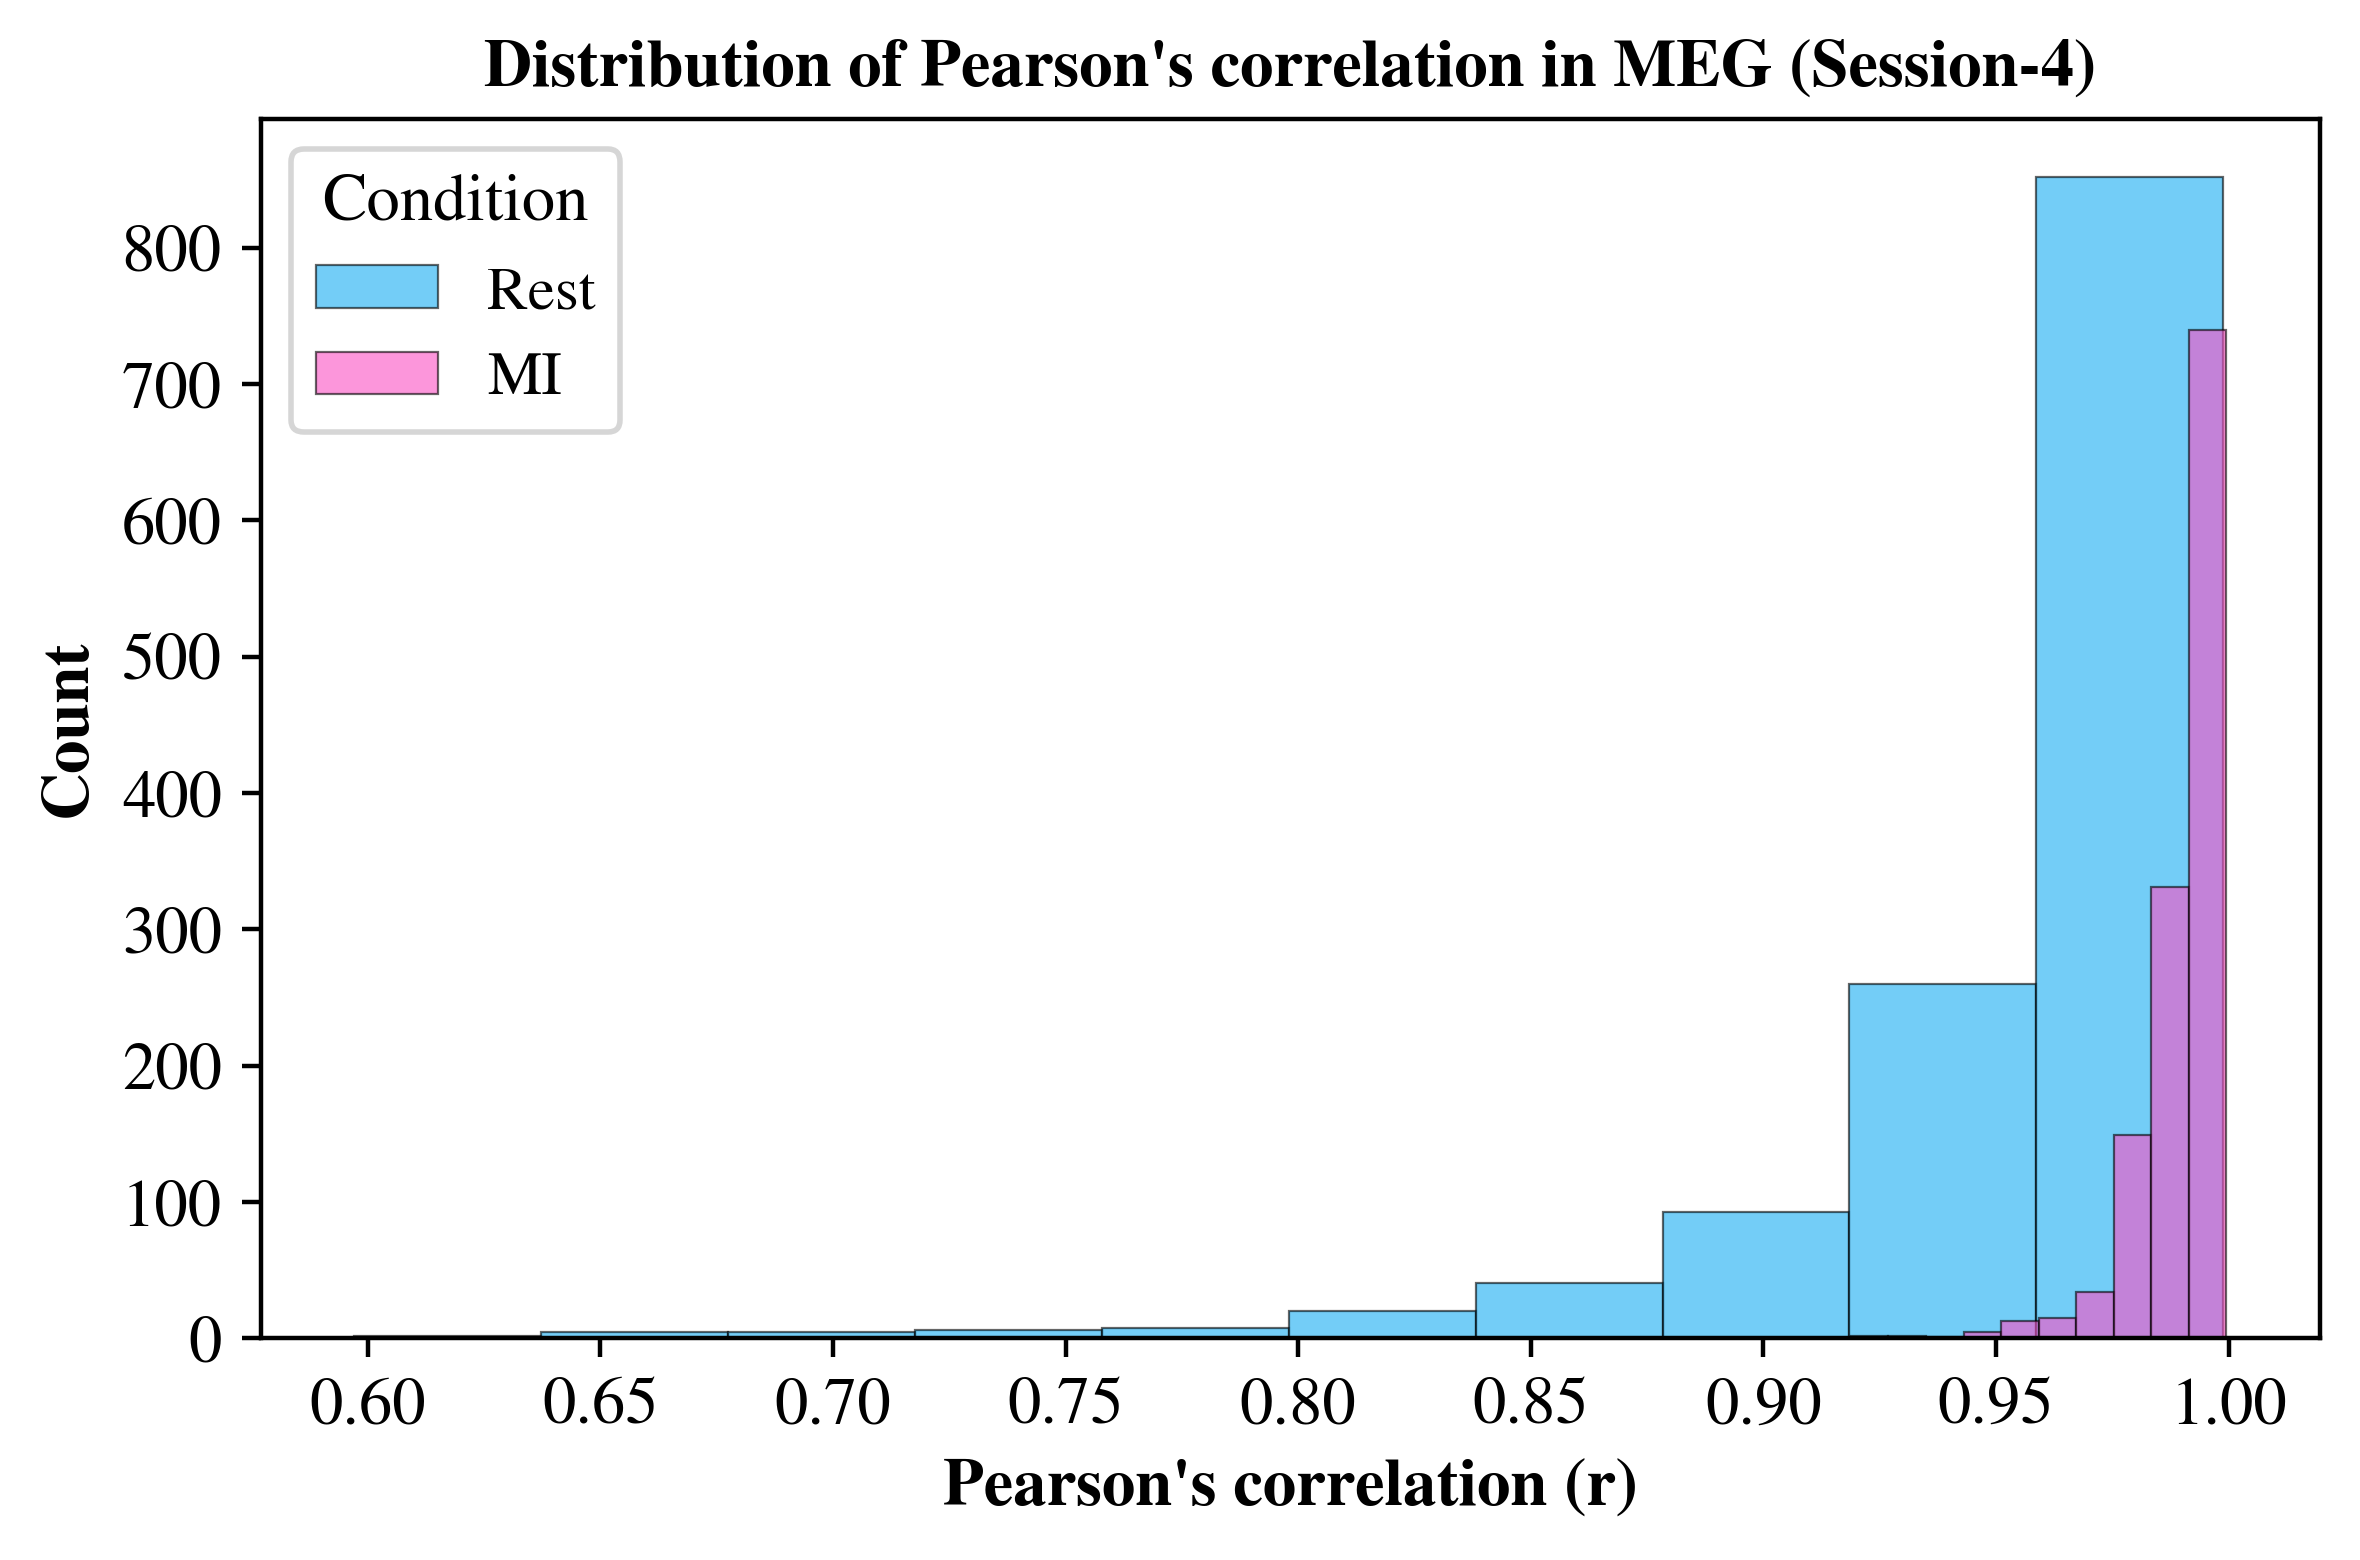

In [13]:
# SESSION-4
col_rs = "#16ACF2" 
col_mi = "#FA50C4" 

plt.figure(figsize=(6, 4), dpi=400)
plt.hist(x_rest_all[4][:, 5, :].flatten(), label='Rest', alpha=0.6, color=col_rs, edgecolor='black',  linewidth=0.4)
plt.hist(x_mi_all[4][:, 5, :].flatten(), label='MI', alpha=0.6, color=col_mi, edgecolor='black',  linewidth=0.4)

plt.xlabel("Pearson's correlation (r)", fontsize=12, fontweight='bold', color='black')
plt.ylabel("Count", fontsize=12, fontweight='bold', color='black')
plt.title("Distribution of Pearson's correlation in MEG (Session-4)", fontsize=12, fontweight='bold', color='black')



plt.grid(False)
plt.legend(title='Condition', fontsize=11, title_fontsize=12, frameon=True)

plt.tight_layout()
plt.show()



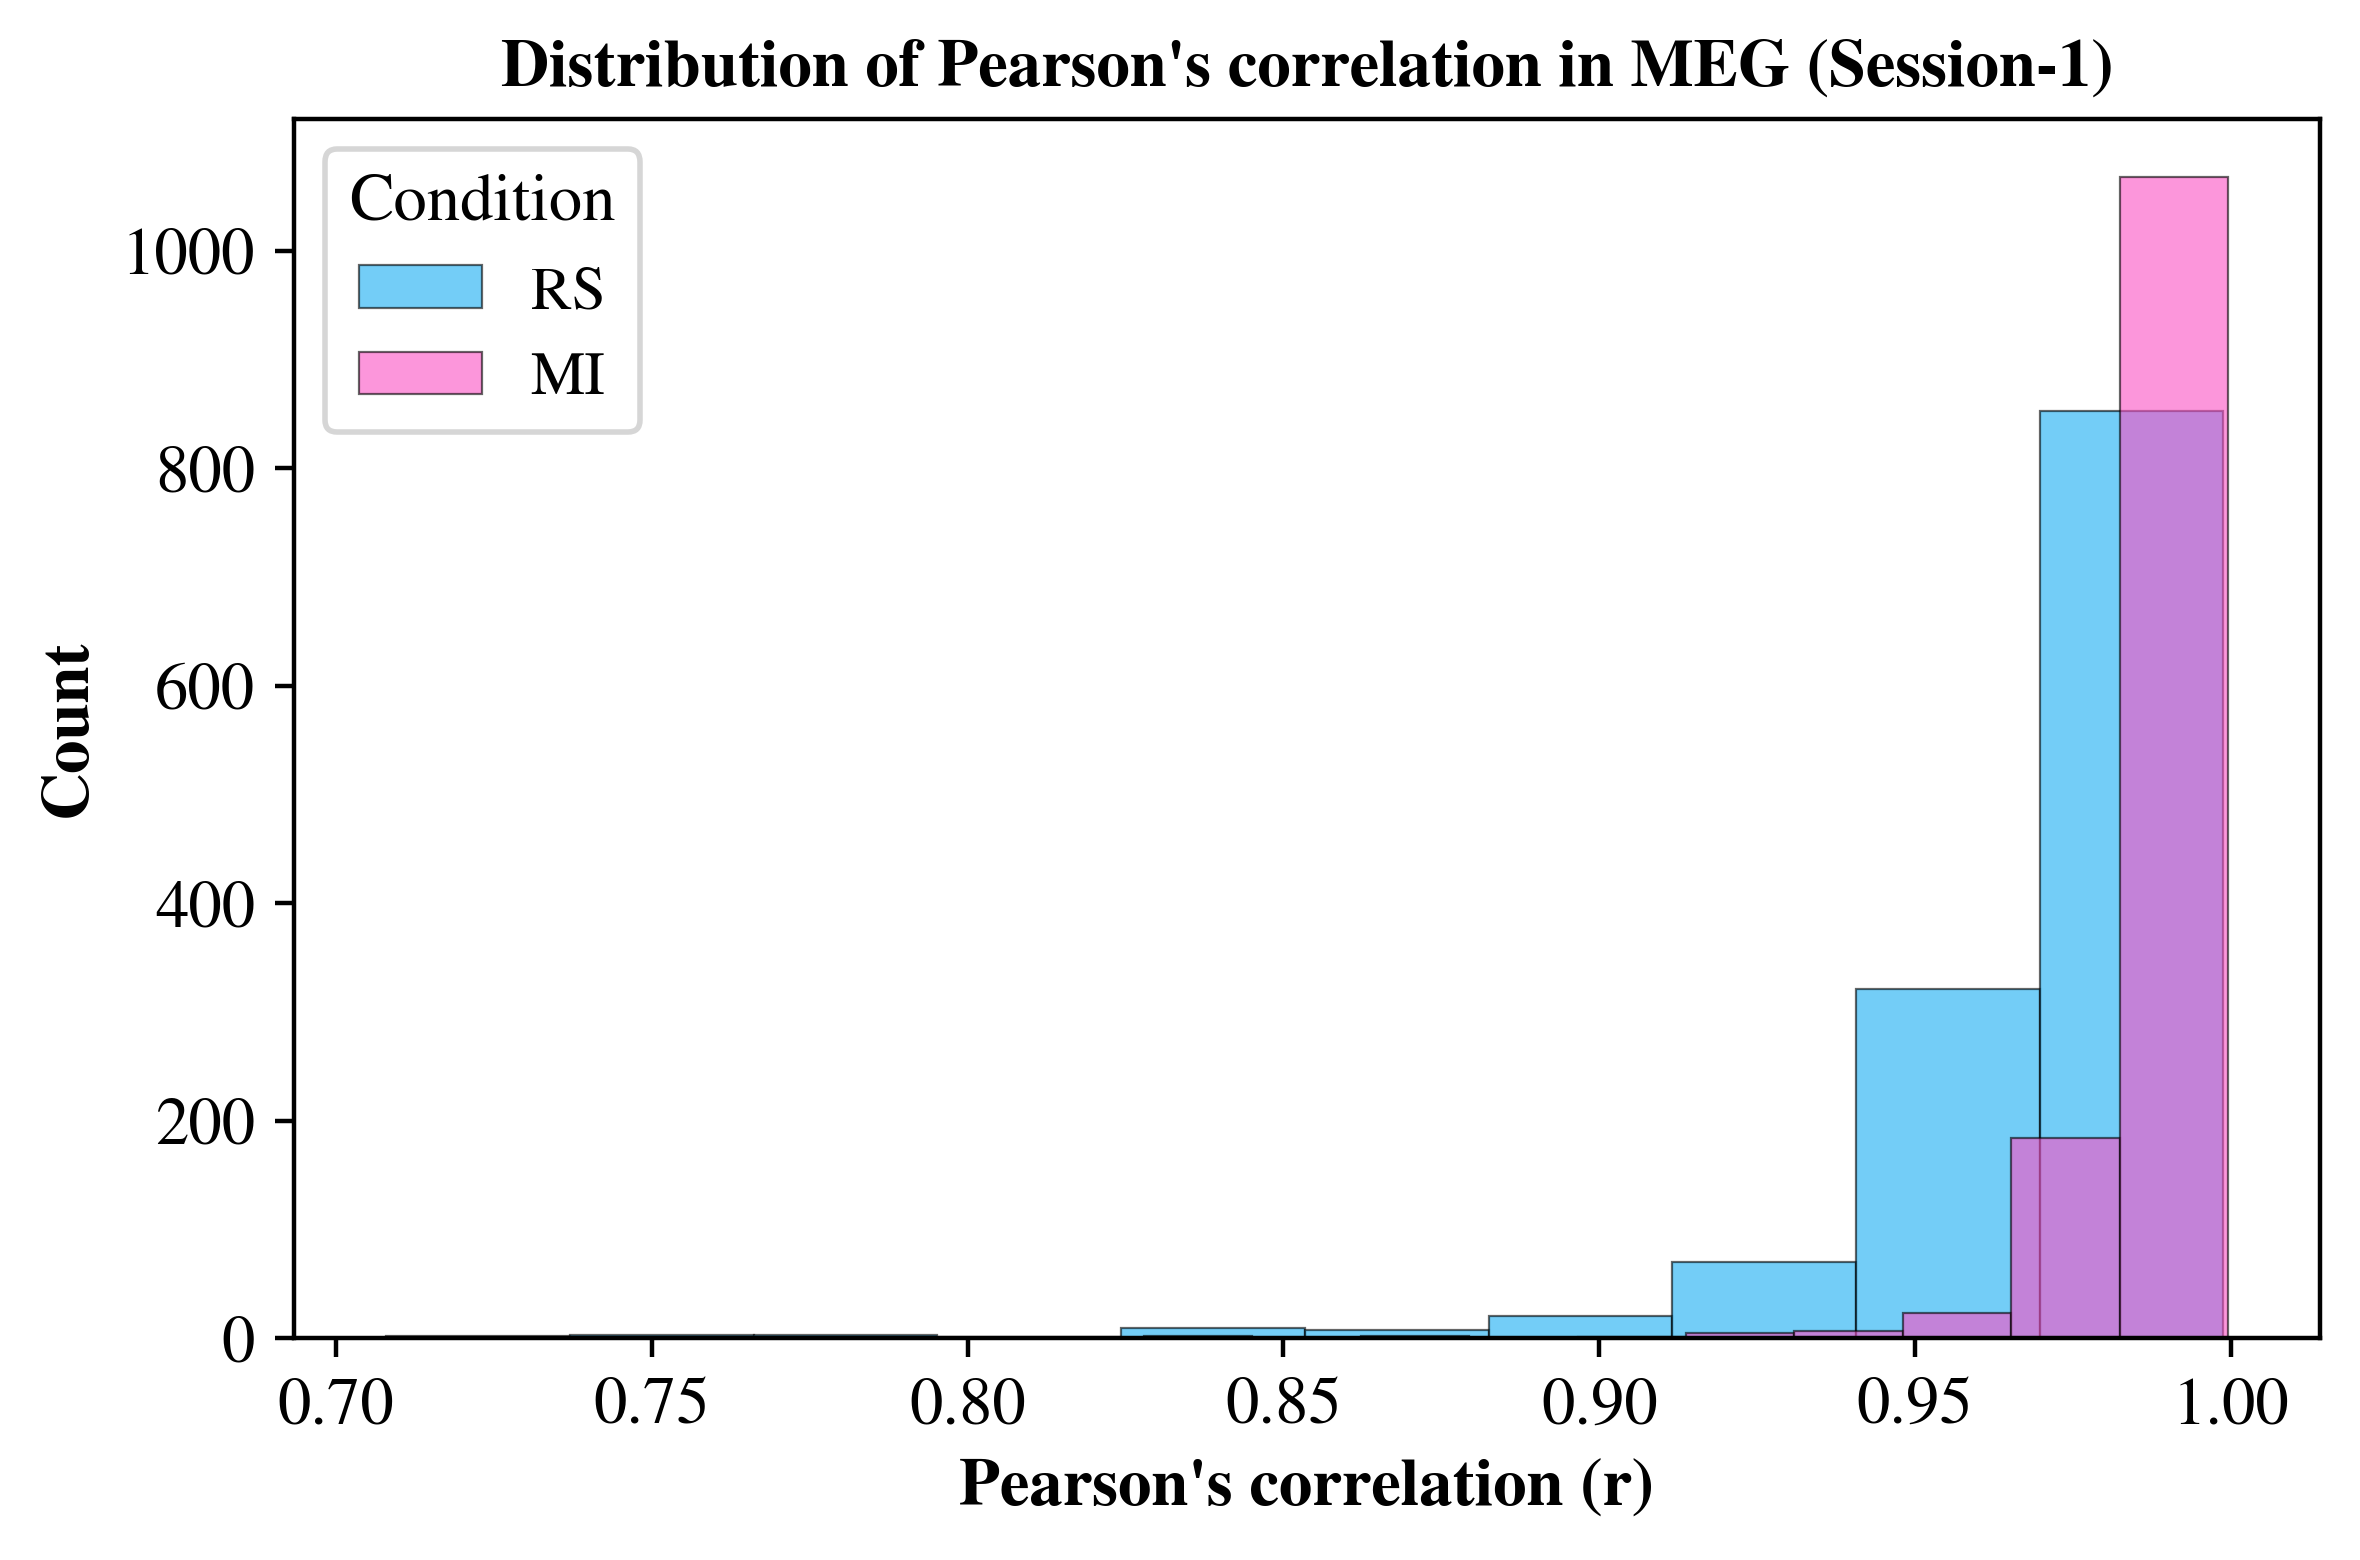

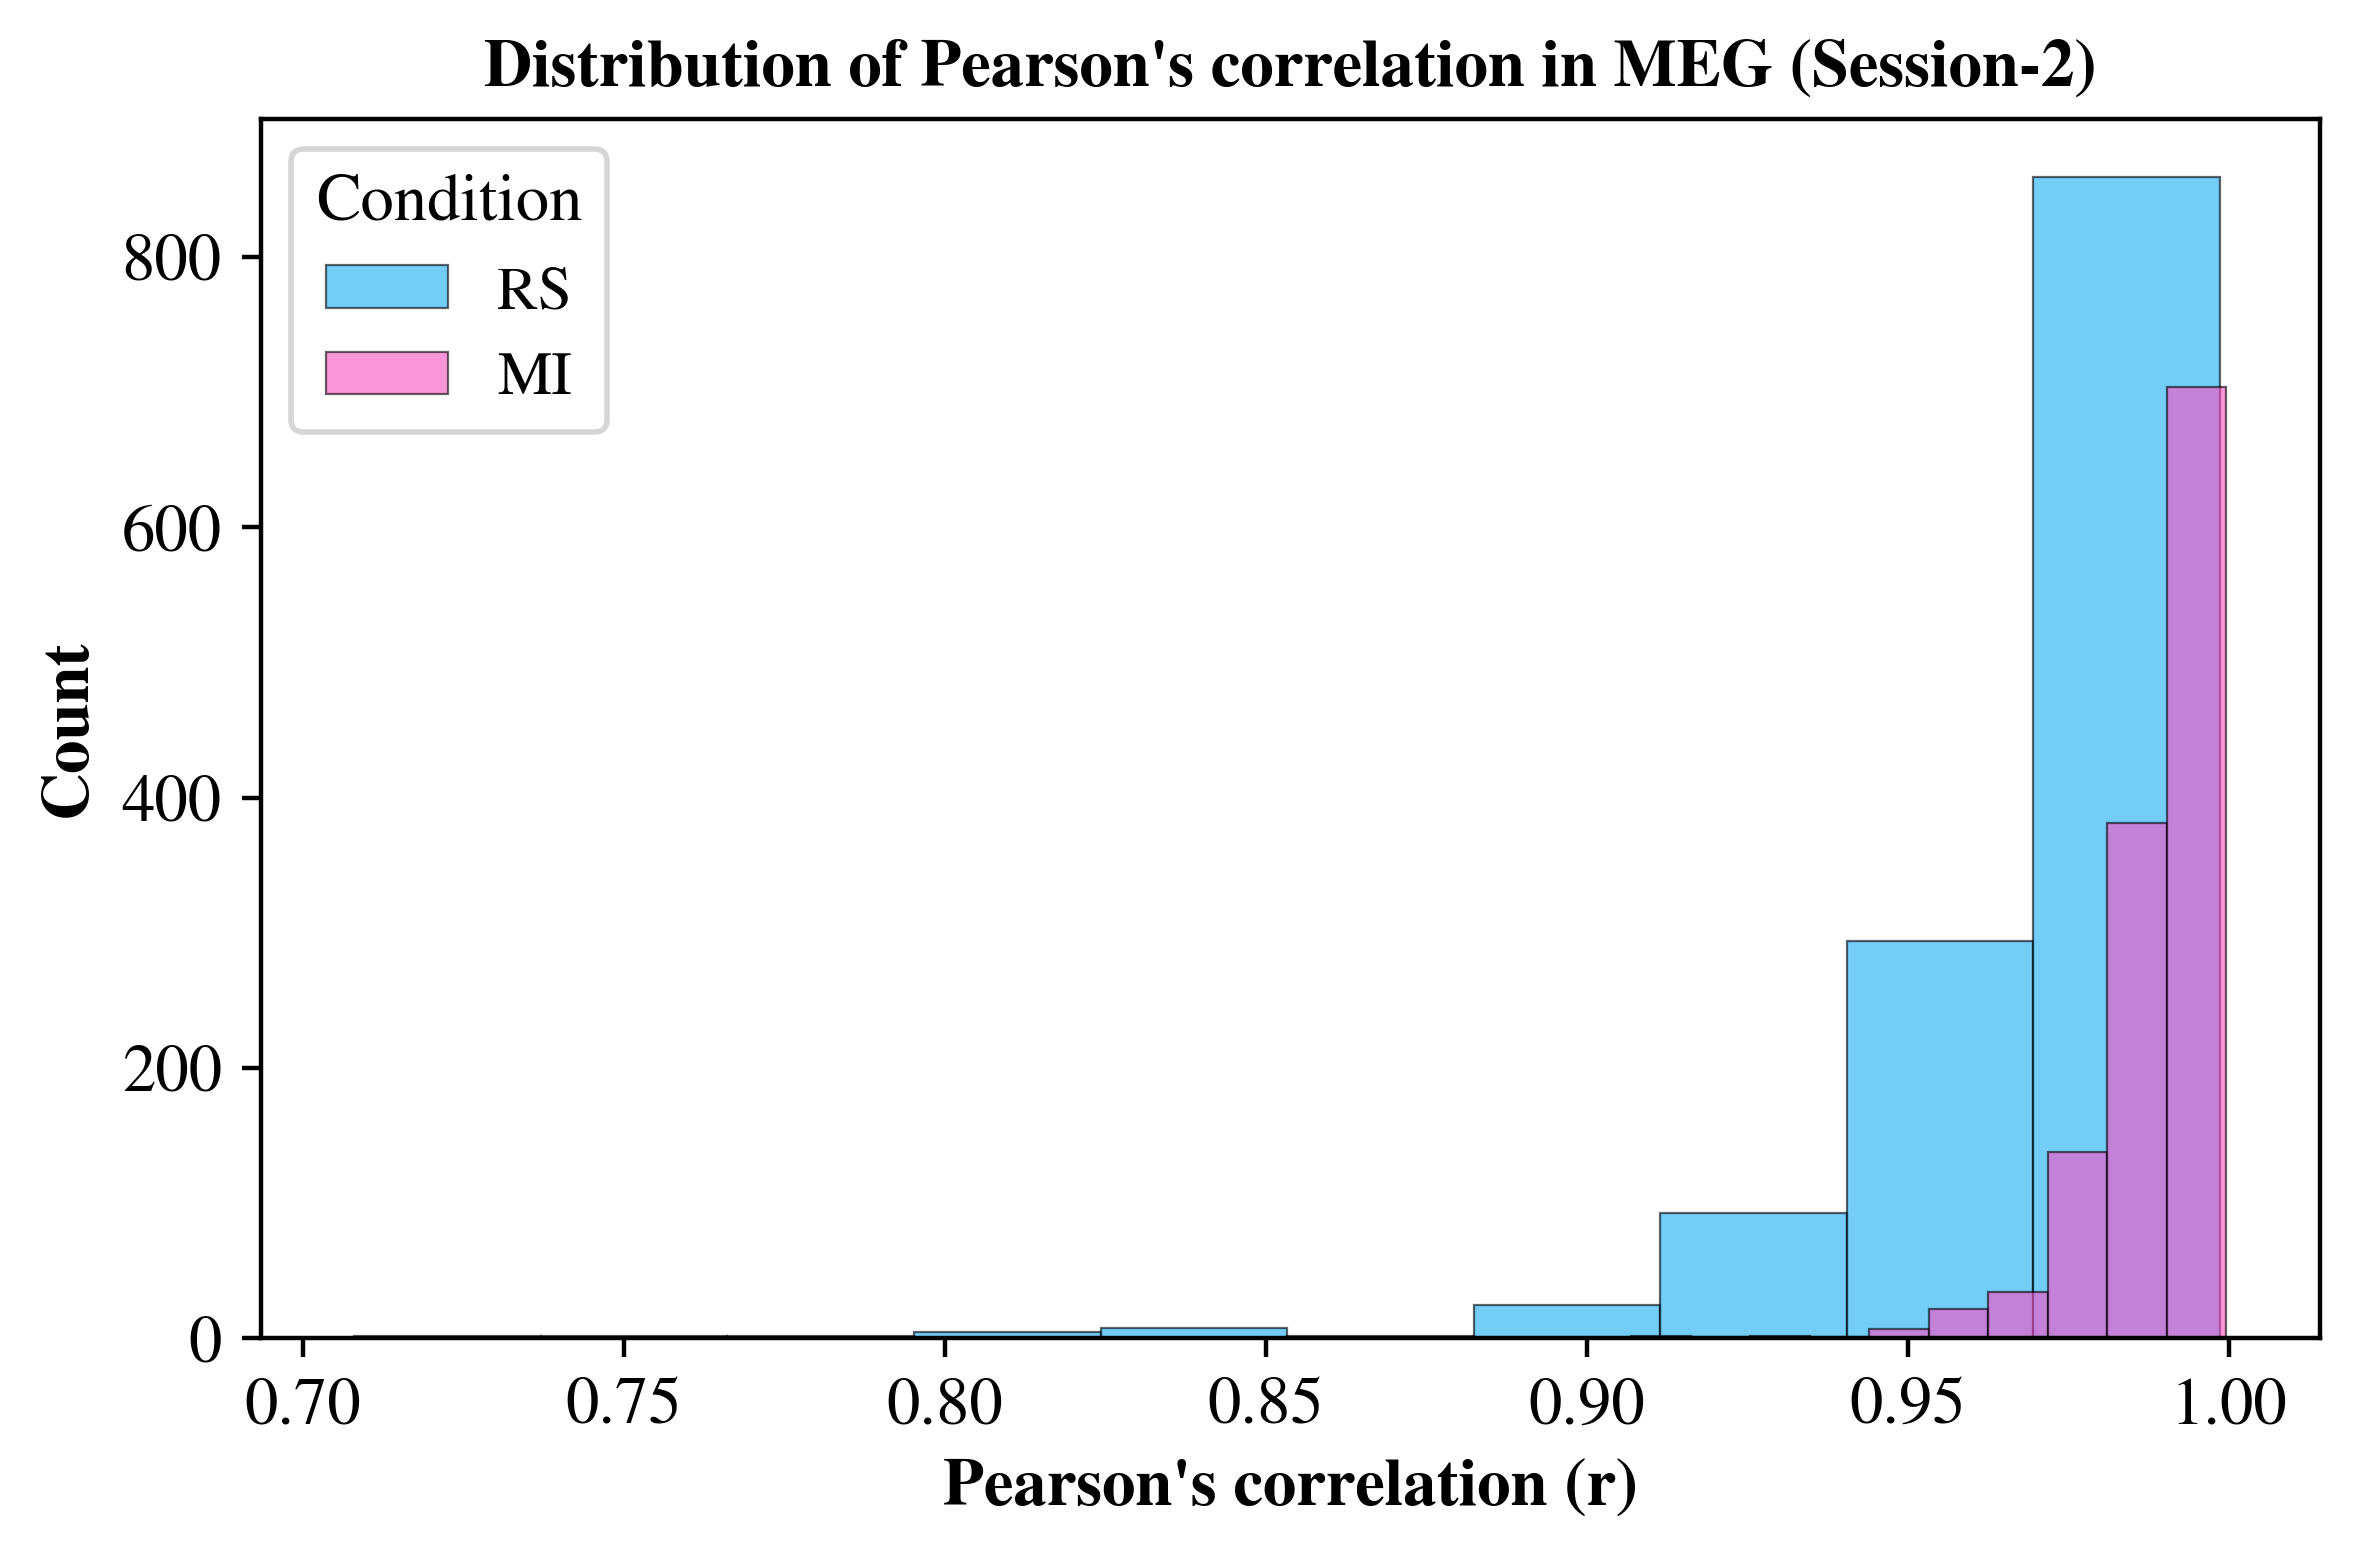

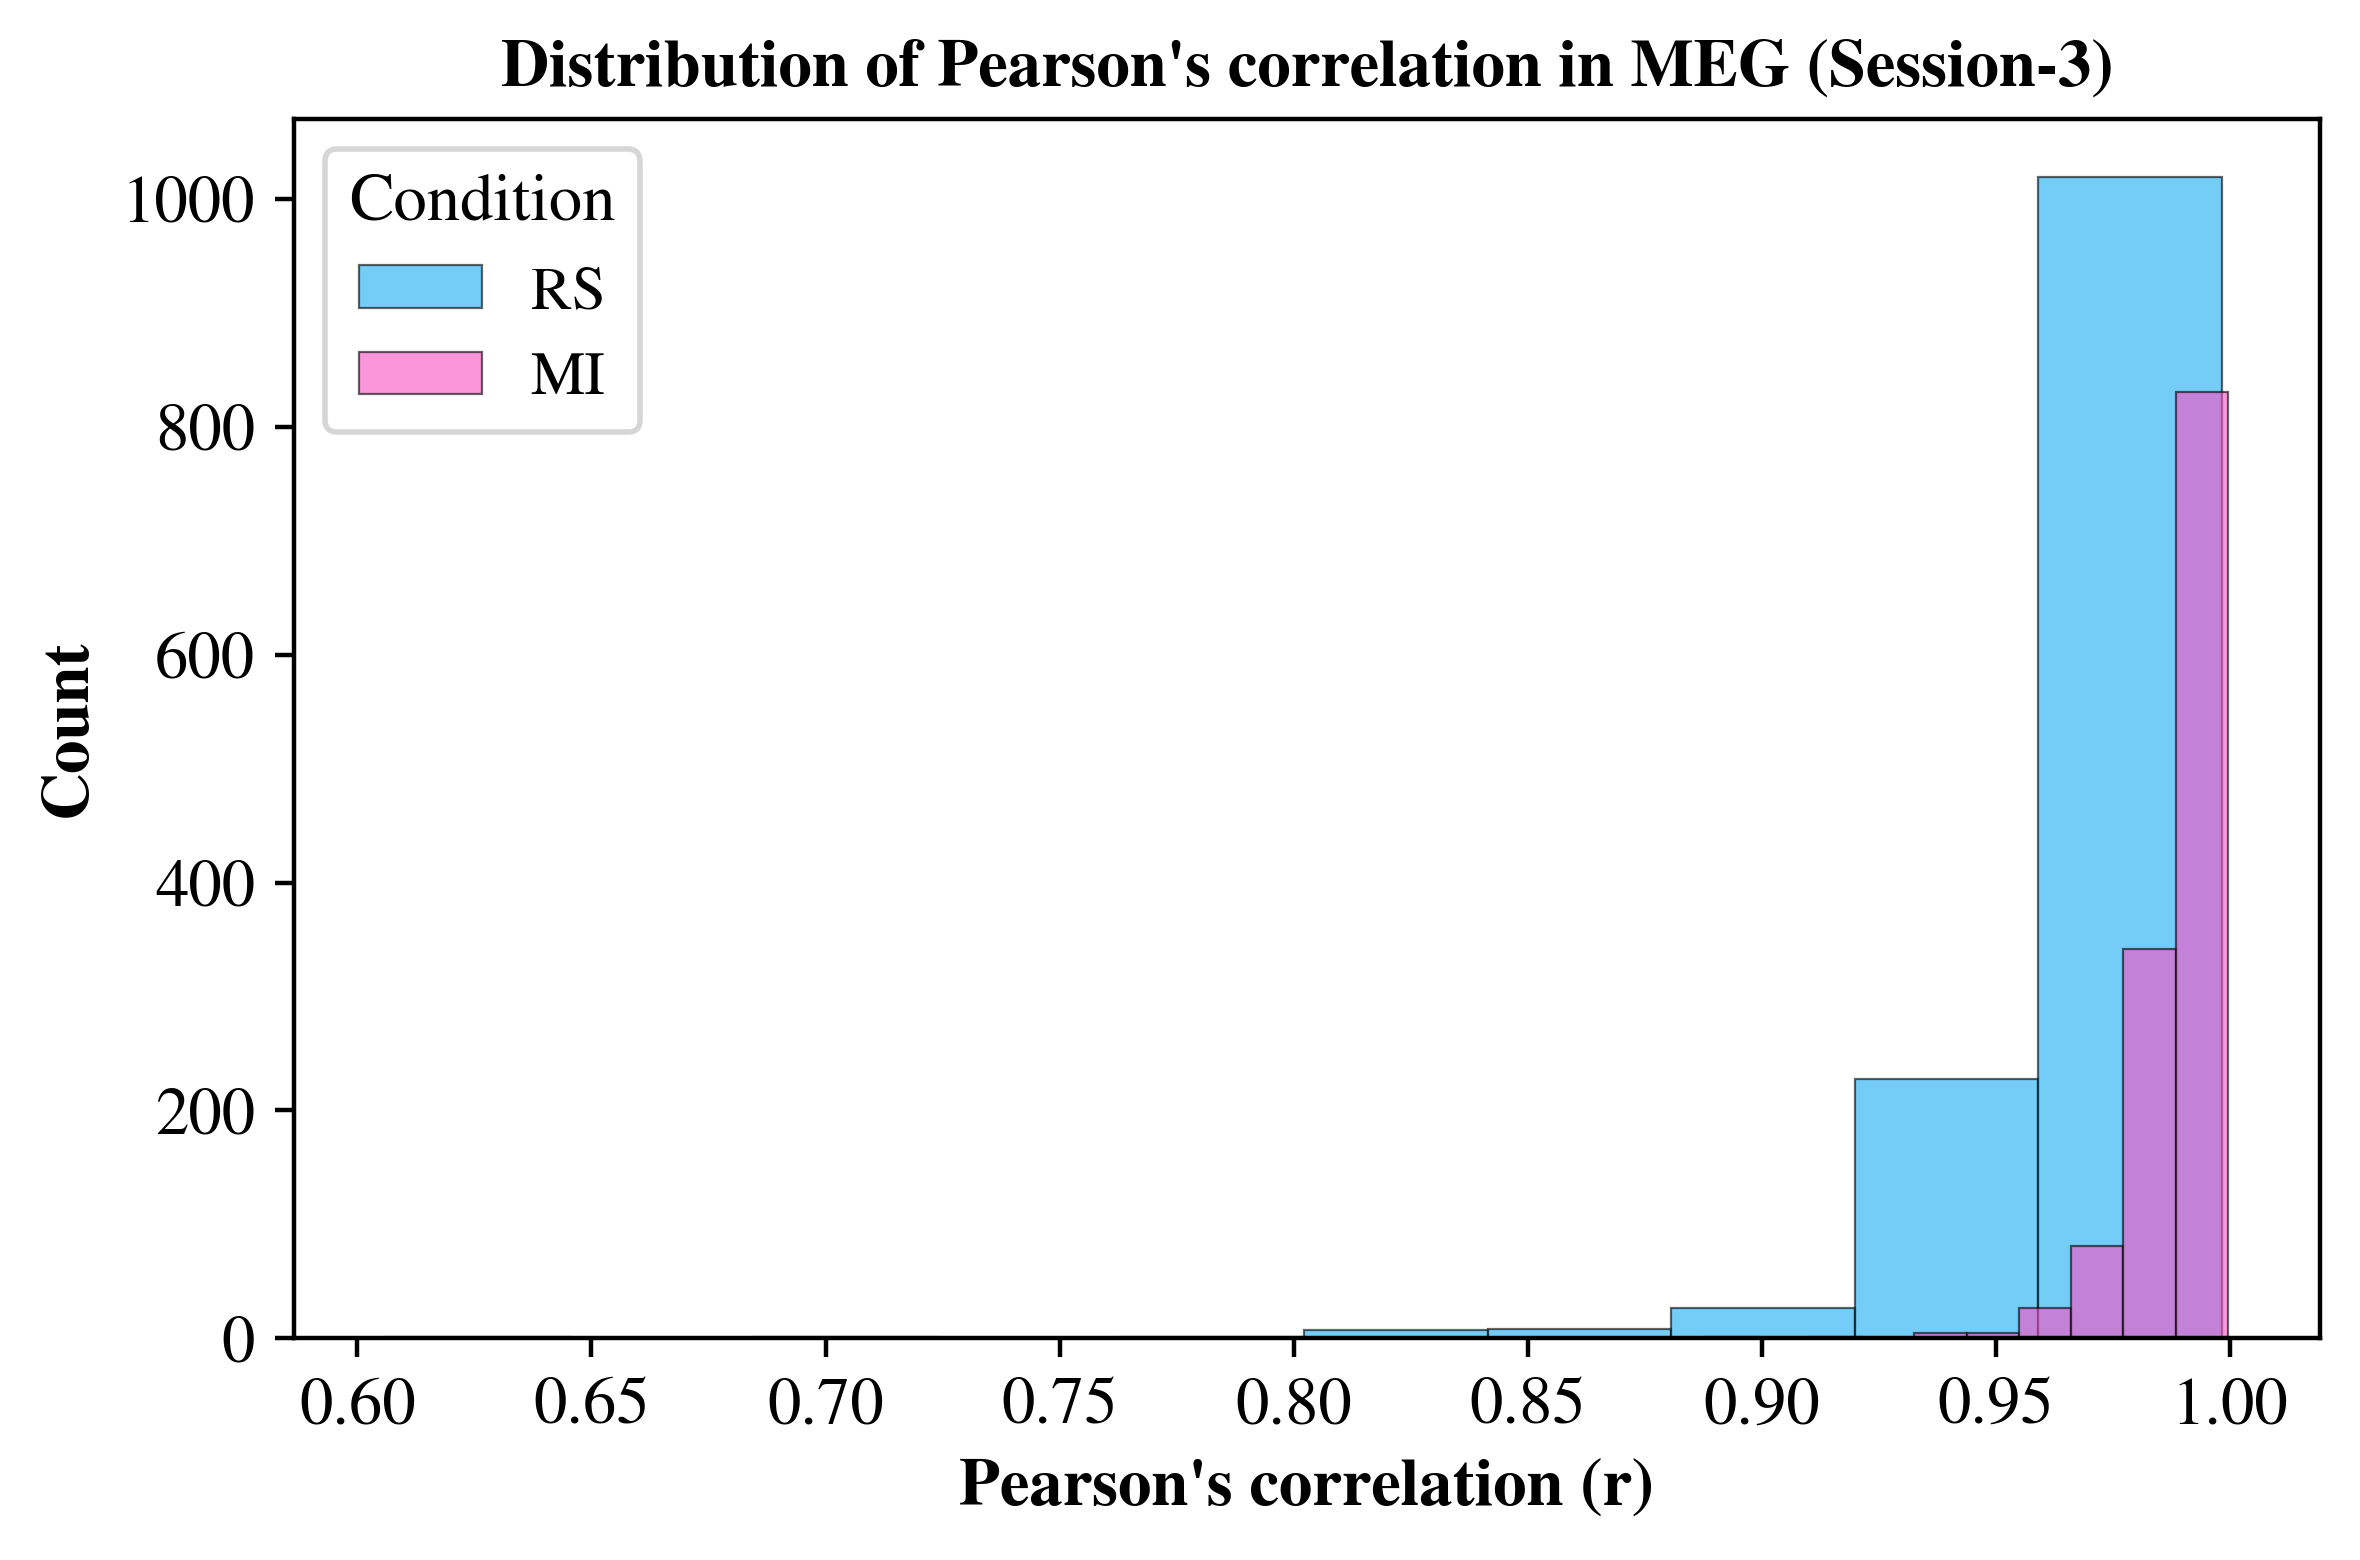

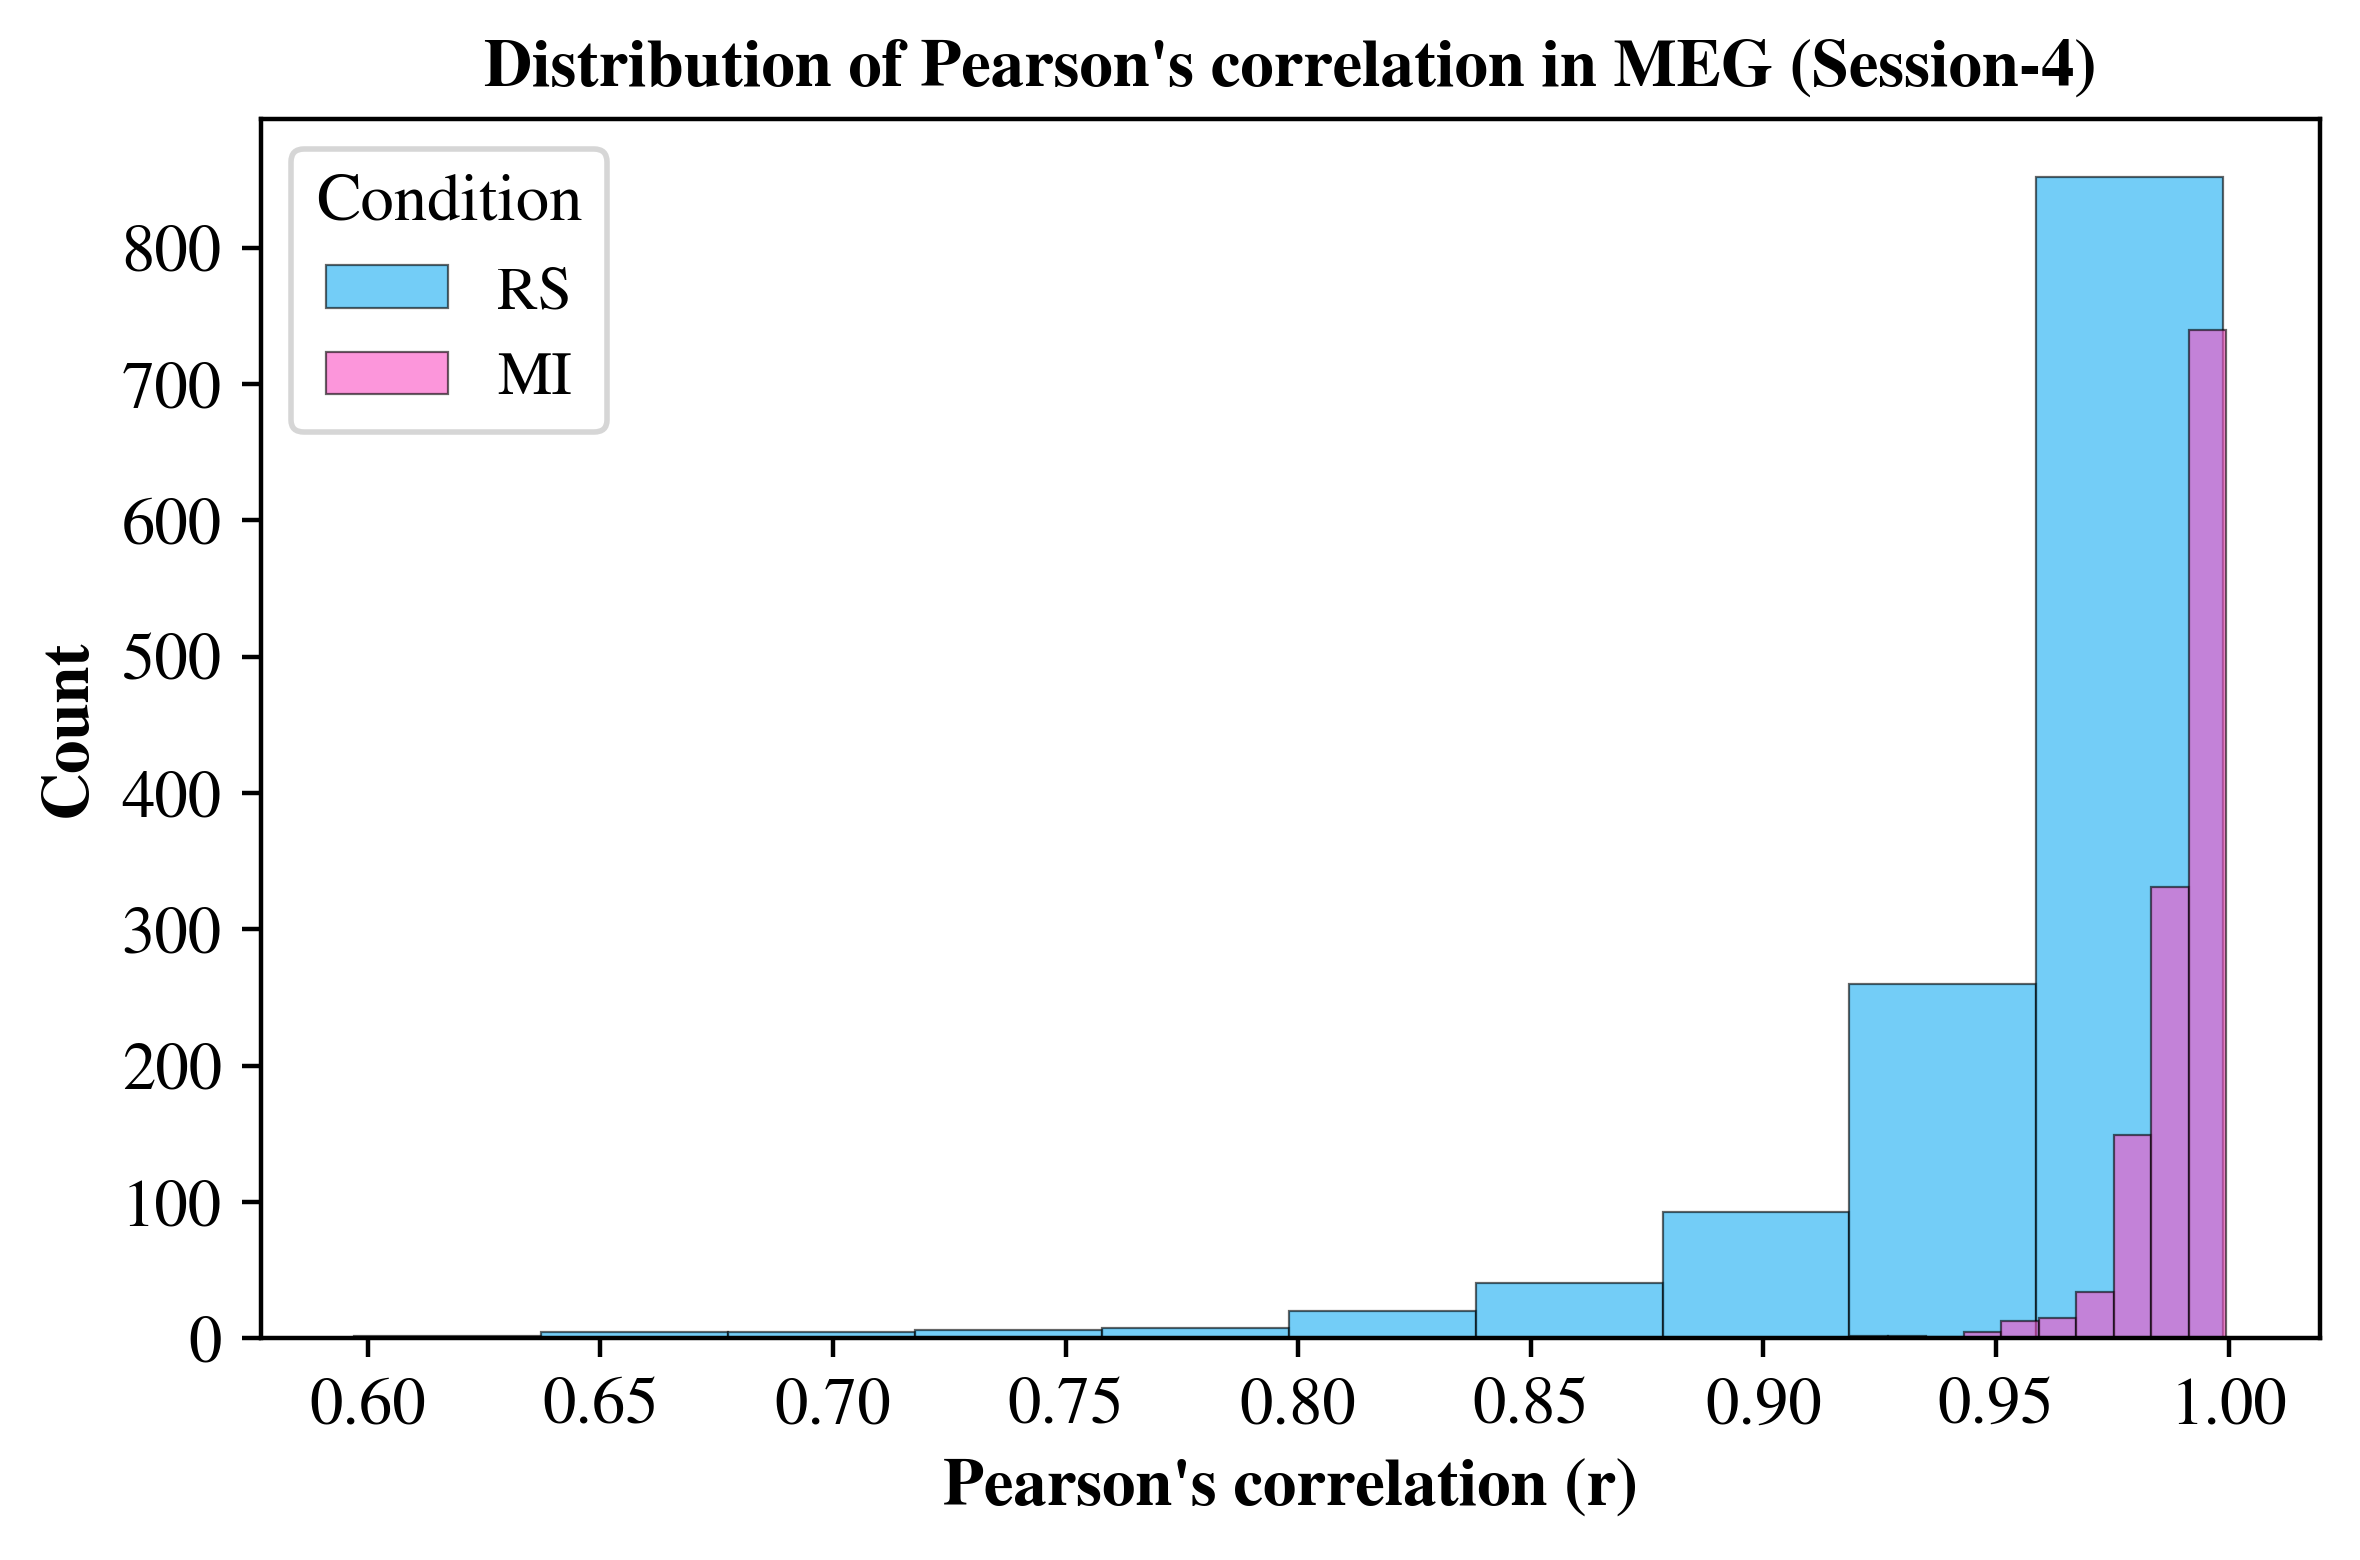

In [8]:
#all the sessions
col_rs = "#16ACF2" 
col_mi = "#FA50C4" 

for i in range(1,5):
    plt.figure(figsize=(6, 4), dpi=400)
    plt.hist(x_rest_all[i][:, 5, :].flatten(), label='RS', alpha=0.6, color=col_rs, edgecolor='black',  linewidth=0.4)
    plt.hist(x_mi_all[i][:, 5, :].flatten(), label='MI', alpha=0.6, color=col_mi, edgecolor='black',  linewidth=0.4)

    plt.xlabel("Pearson's correlation (r)", fontsize=12, fontweight='bold', color='black')
    plt.ylabel("Count", fontsize=12, fontweight='bold', color='black')
    plt.title(f"Distribution of Pearson's correlation in MEG (Session-{i})", fontsize=12, fontweight='bold', color='black')

    plt.grid(False)
    plt.legend(title='Condition', fontsize=11, title_fontsize=12, frameon=True)

    plt.tight_layout()
    plt.show()



In [18]:
#regions with index
for idx, val in enumerate(all_regions):
    print(idx,val)

0 'bankssts L'
1 'bankssts R'
2 'caudalanteriorcingulate L'
3 'caudalanteriorcingulate R'
4 'caudalmiddlefrontal L'
5 'caudalmiddlefrontal R'
6 'cuneus L'
7 'cuneus R'
8 'entorhinal L'
9 'entorhinal R'
10 'frontalpole L'
11 'frontalpole R'
12 'fusiform L'
13 'fusiform R'
14 'inferiorparietal L'
15 'inferiorparietal R'
16 'inferiortemporal L'
17 'inferiortemporal R'
18 'insula L'
19 'insula R'
20 'isthmuscingulate L'
21 'isthmuscingulate R'
22 'lateraloccipital L'
23 'lateraloccipital R'
24 'lateralorbitofrontal L'
25 'lateralorbitofrontal R'
26 'lingual L'
27 'lingual R'
28 'medialorbitofrontal L'
29 'medialorbitofrontal R'
30 'middletemporal L'
31 'middletemporal R'
32 'paracentral L'
33 'paracentral R'
34 'parahippocampal L'
35 'parahippocampal R'
36 'parsopercularis L'
37 'parsopercularis R'
38 'parsorbitalis L'
39 'parsorbitalis R'
40 'parstriangularis L'
41 'parstriangularis R'
42 'pericalcarine L'
43 'pericalcarine R'
44 'postcentral L'
45 'postcentral R'
46 'posteriorcingulate L

## Sample regions modeled vs actual in MI and RS

In [27]:
## For MI Condition
imp_roi_idx=[38]
rois_interest= ['parsorbitalis L']
for roi_idx, roi in enumerate(imp_roi_idx):
    print(rois_interest[roi_idx])



parsorbitalis L


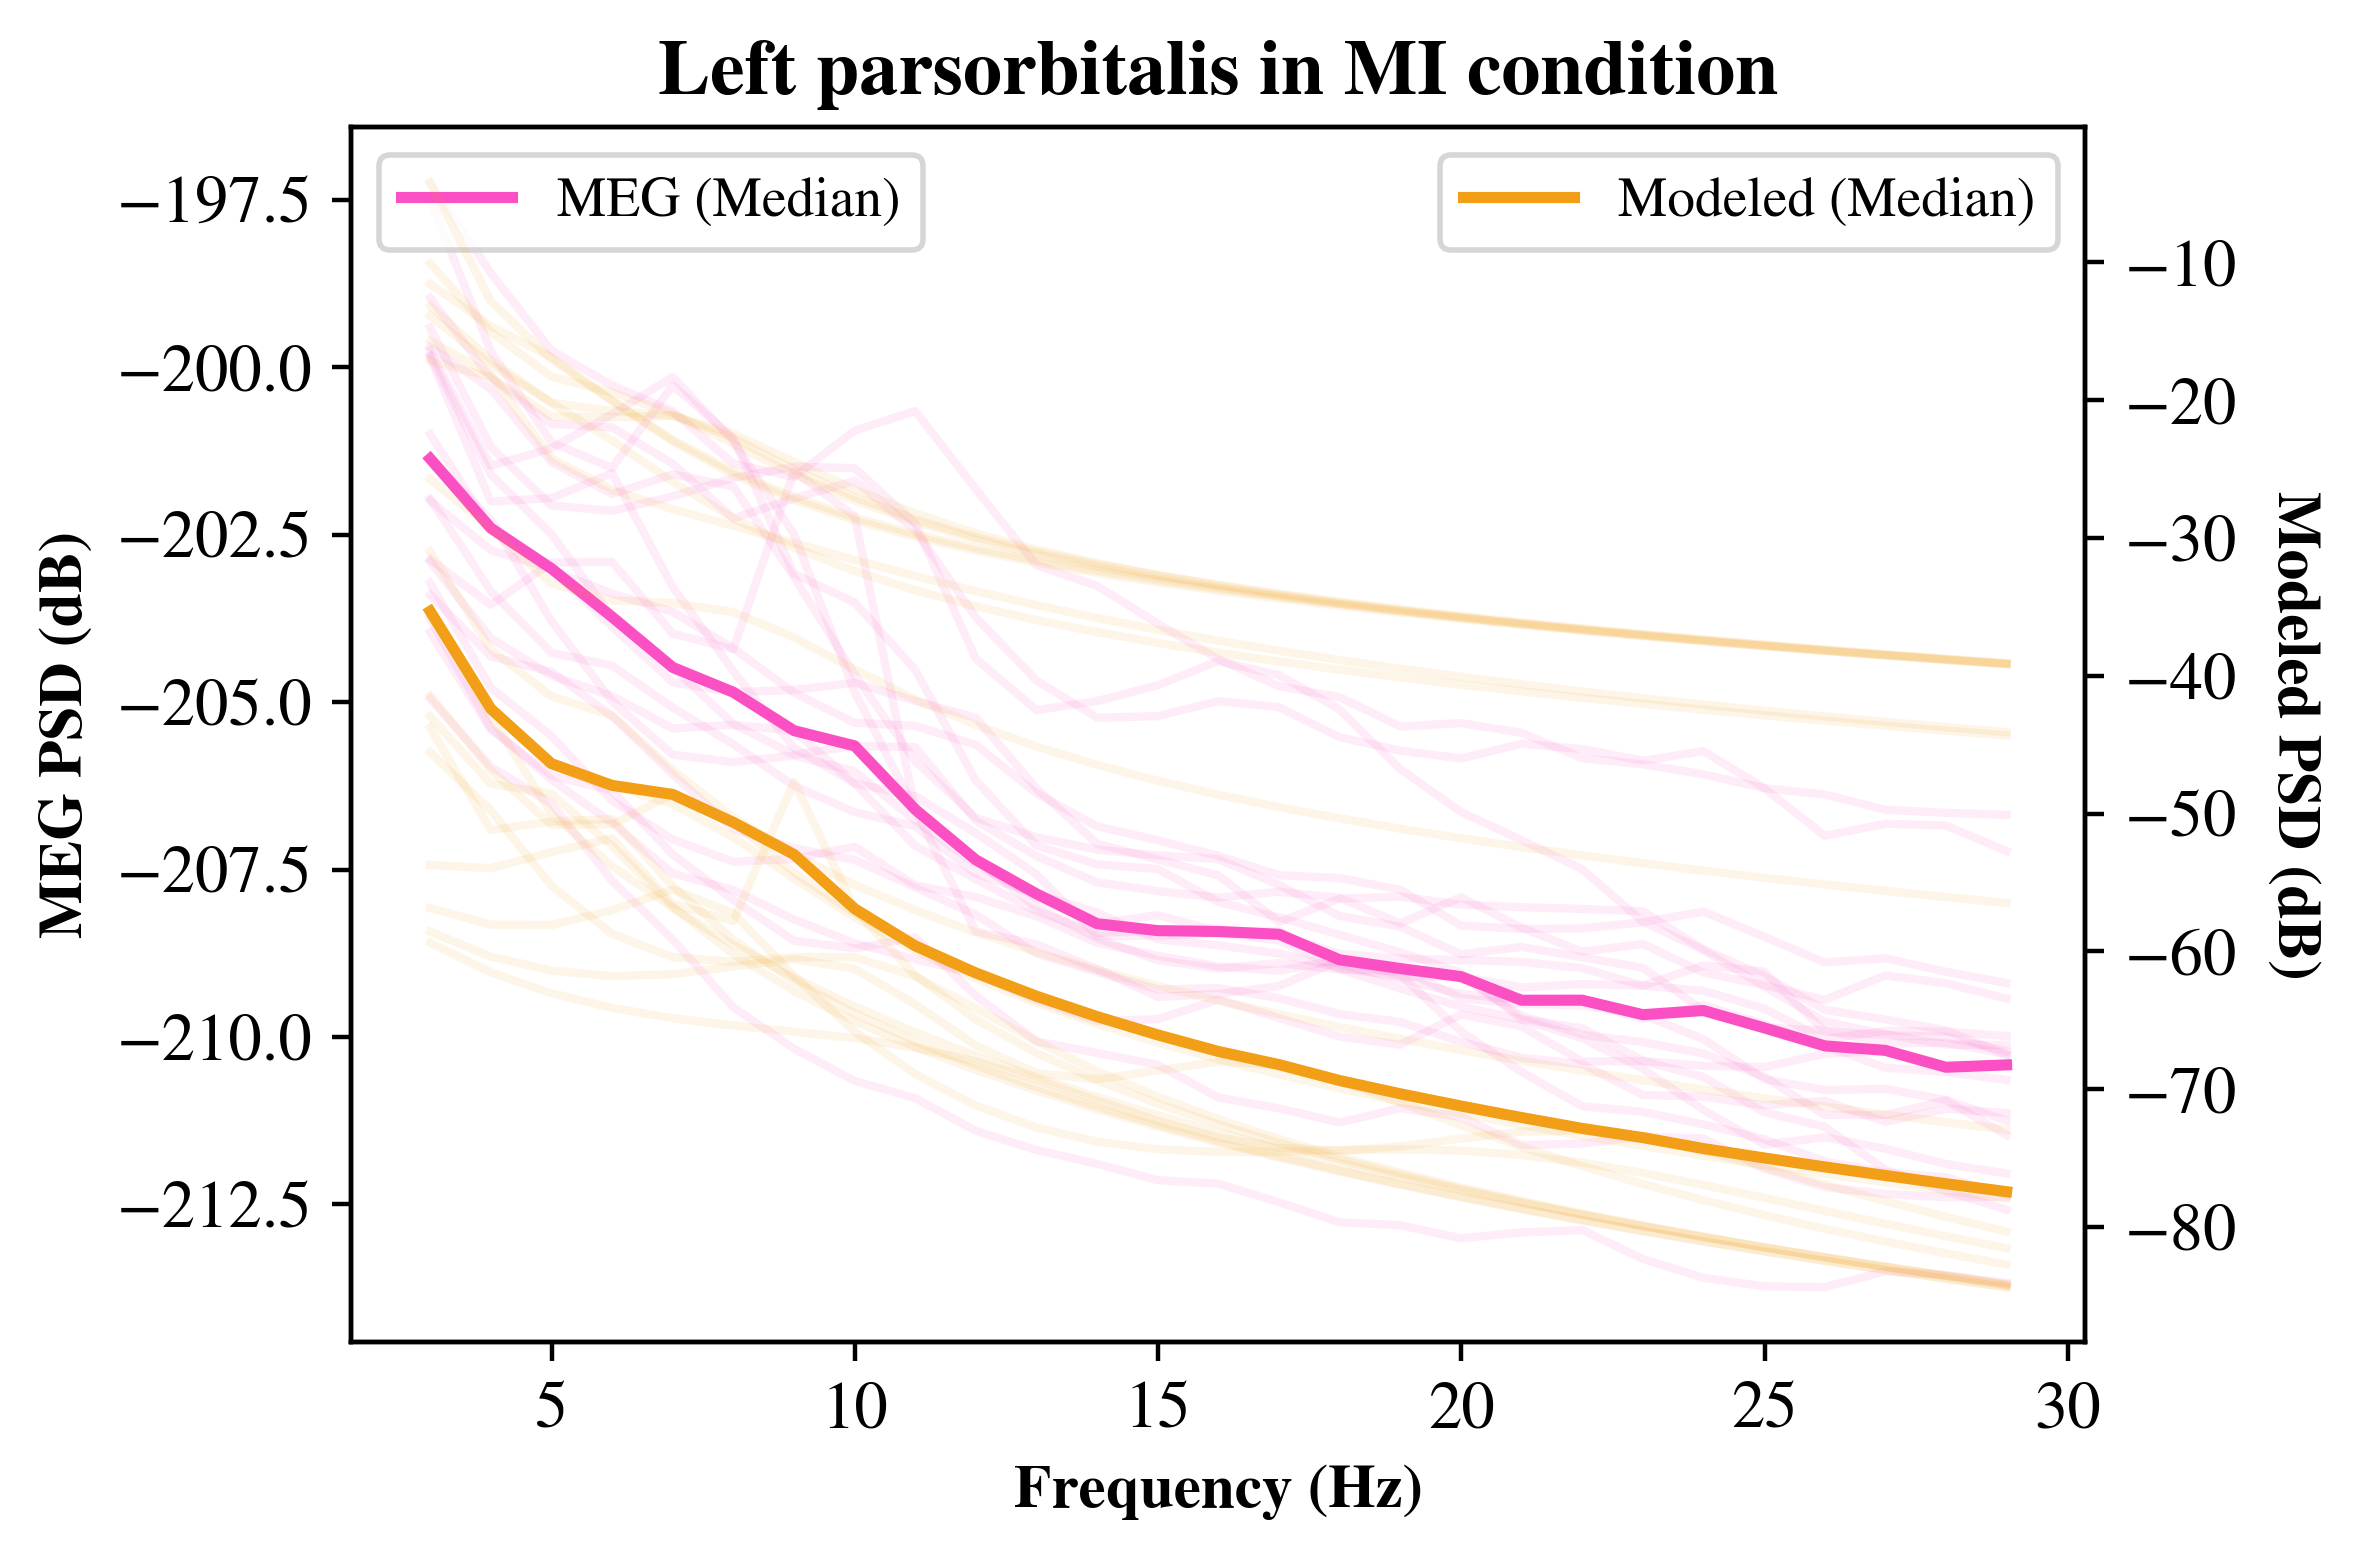

In [28]:
#One sample region for modeled vs Actual in MI condition
col_mod = "#F29E16" 
col_actual = "#FA50C4" 

num_rois=len(imp_roi_idx)
cols = 1
rows = num_rois
fig, ax = plt.subplots(rows, cols, figsize=(6, rows*4), dpi=400)

if rows == 1:
    ax = [ax]
for roi_idx, roi in enumerate(imp_roi_idx):
    roi_name = rois_interest[roi_idx]
    
    # Left: MEG PSD
    for i in range(19):
        ax[roi_idx].plot(fvec, 10*np.log10(sess4_mi_avg[i, roi, 3:30]), color=col_actual, alpha=0.1)
    spectra_eeg_mi = 10*np.log10(np.median(sess4_mi_avg[:, roi, 3:30], axis=0))
    ax[roi_idx].plot(fvec, spectra_eeg_mi, color=col_actual, label='MEG (Median)', linewidth=2)

    ax[roi_idx].set_title(f"Left {roi_name[:-2]} in MI condition", fontsize=14, fontweight="bold")
    ax[roi_idx].set_xlabel("Frequency (Hz)", fontsize=11,fontweight="bold")
    ax[roi_idx].set_ylabel("MEG PSD (dB)", fontsize=11,fontweight="bold")
    ax[roi_idx].legend(fontsize=10, loc='upper left')

    # Right: Modeled PSD
    ax_twin = ax[roi_idx].twinx()
    modeled_spectra_mi = []

    for i in range(19):
        params = {
            "gei": x_mi_all[4][roi, 0, i],
            "gii": x_mi_all[4][roi, 1, i],
            "tau_e": x_mi_all[4][roi, 2, i]/1000,
            "tau_i": x_mi_all[4][roi, 3, i]/1000,
            "pw": x_mi_all[4][roi, 4, i]
        }
        Htotal = nt_nostim.ntf_local(params, fvec)
        modeled_psd = functions.mag2db(Htotal)
        modeled_spectra_mi.append(modeled_psd)
        ax_twin.plot(fvec, modeled_psd, color=col_mod, alpha=0.1)

    spectra_sgm_mi = np.median(modeled_spectra_mi, axis=0)
    ax_twin.plot(fvec, spectra_sgm_mi, color=col_mod, linewidth=2, label='Modeled (Median)')

    ax_twin.set_ylabel("Modeled PSD (dB)", fontsize=11, fontweight="bold", rotation=270, labelpad=15)
    ax_twin.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()


In [29]:
# For RS condition
imp_roi_idx=[16]
rois_interest= ['inferiortemporal L']
for roi_idx, roi in enumerate(imp_roi_idx):
    print(rois_interest[roi_idx])

inferiortemporal L


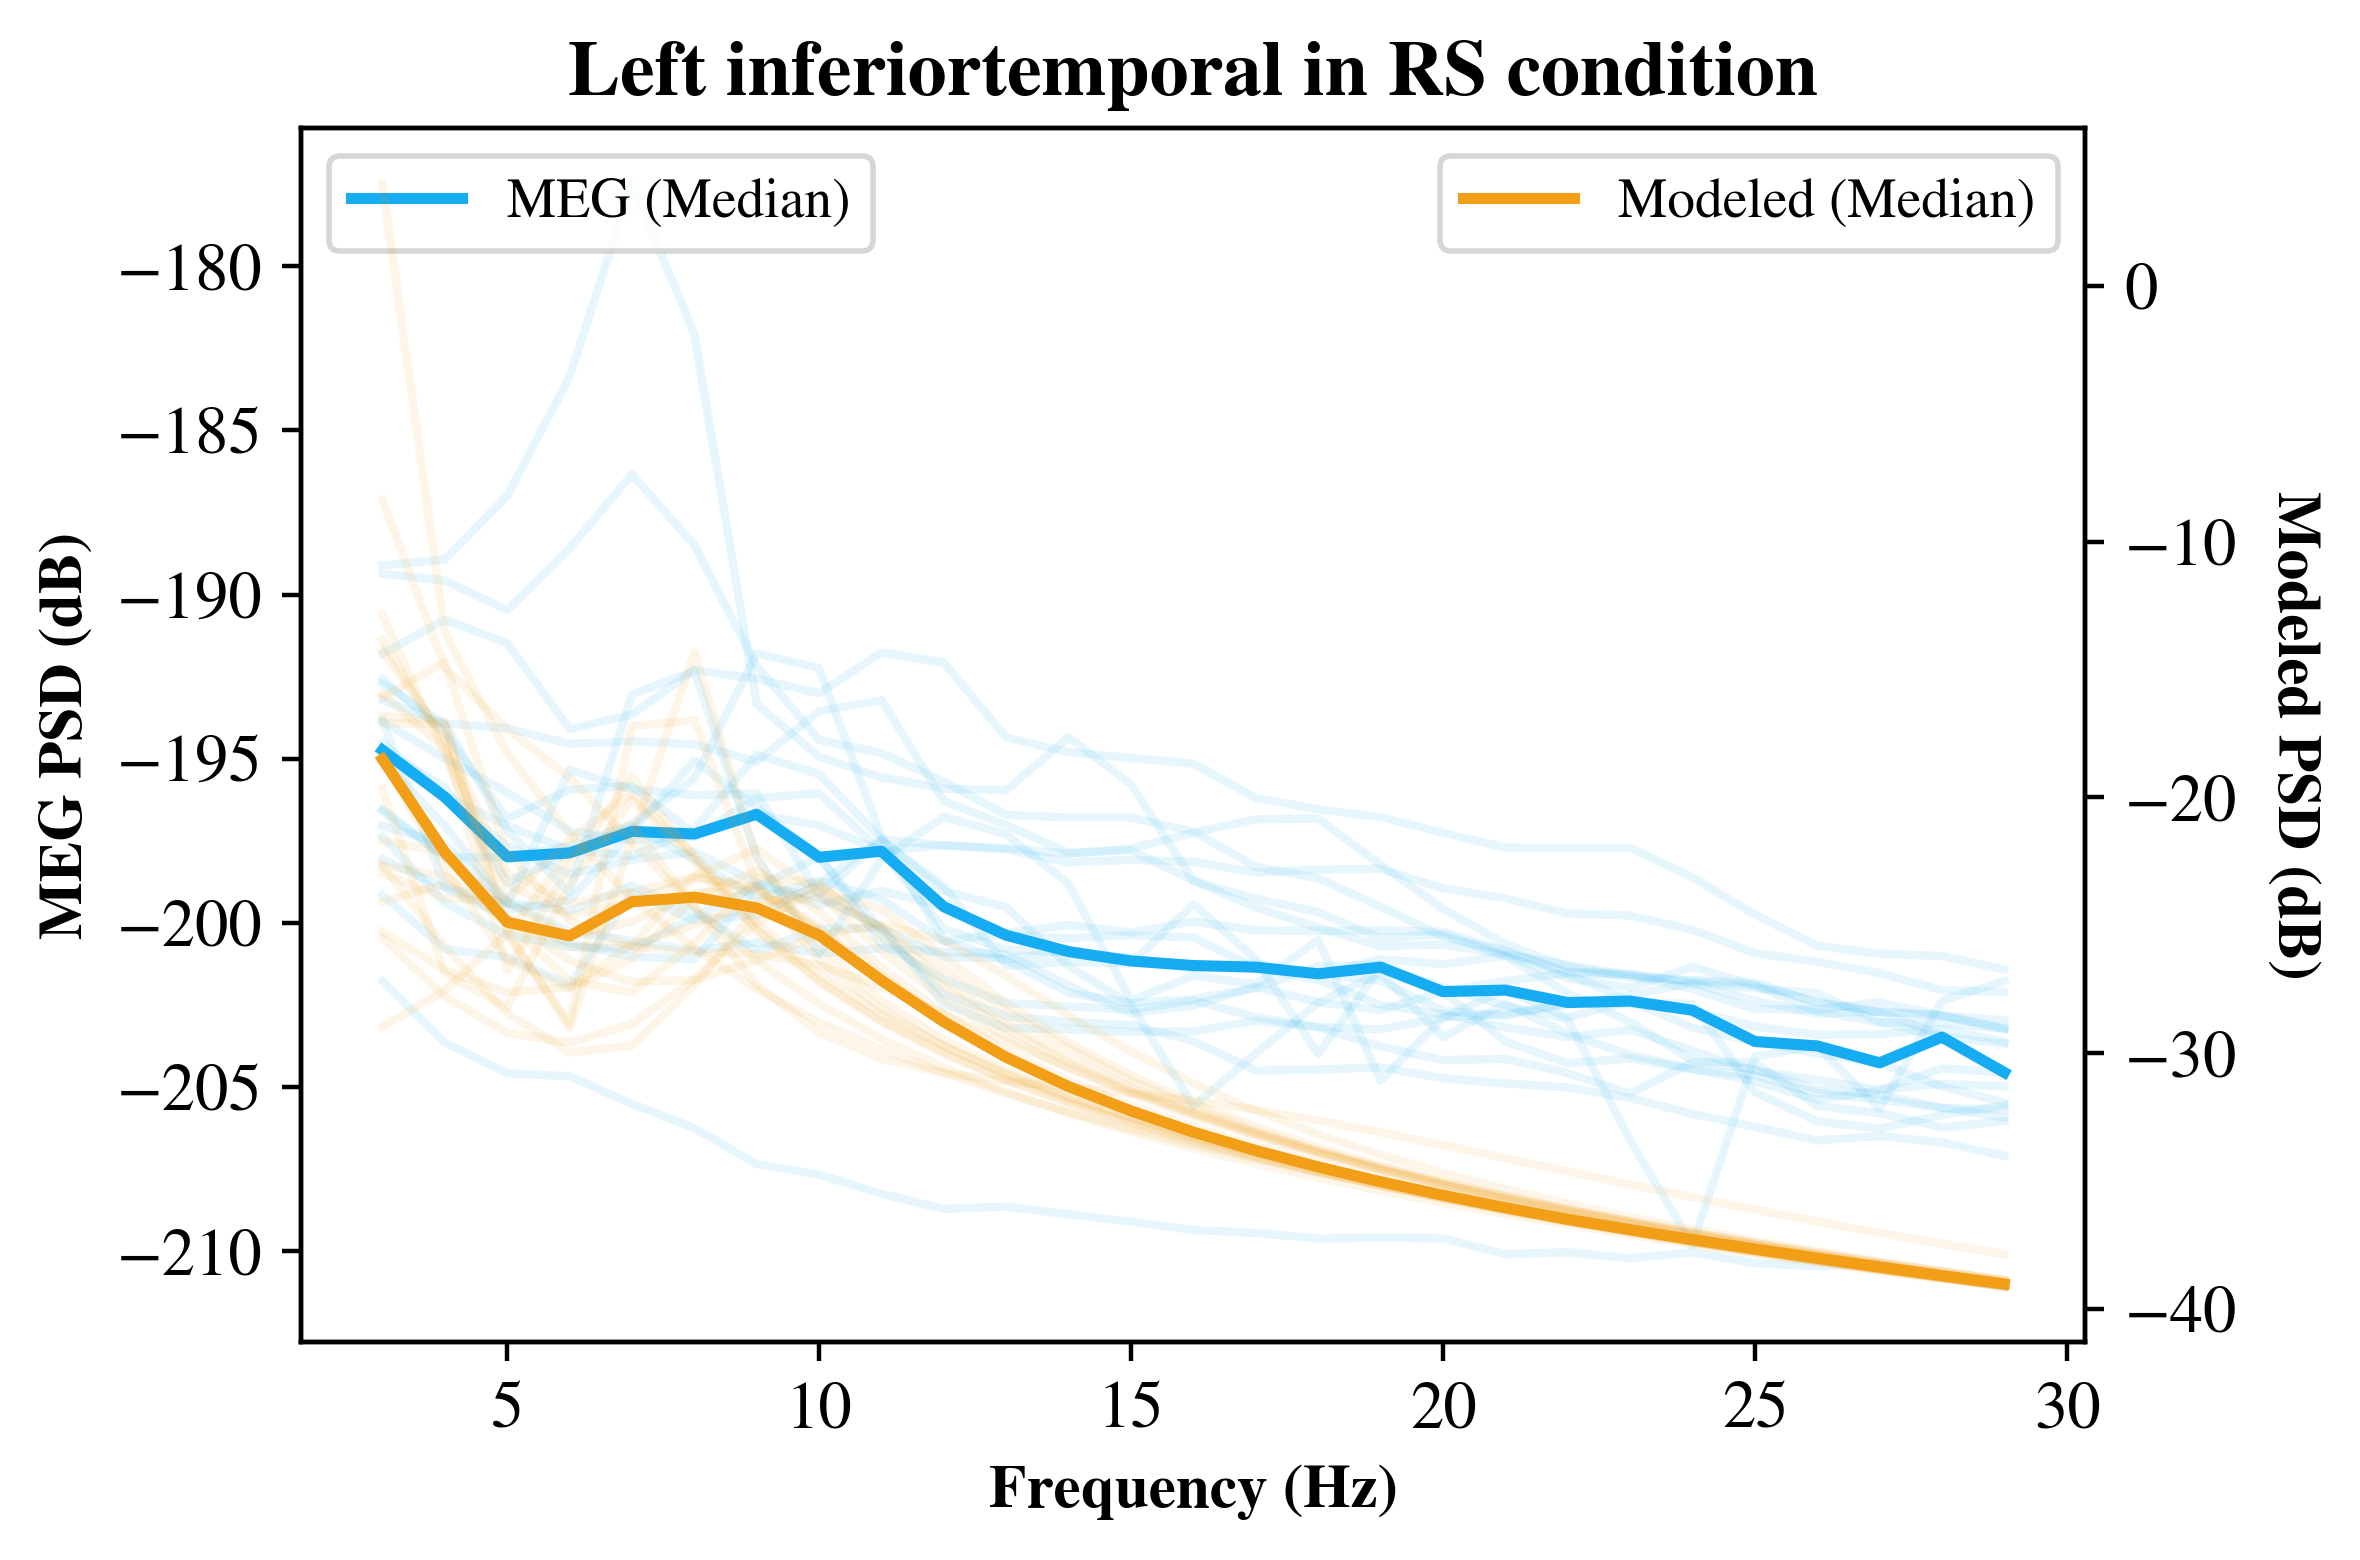

In [30]:
#One sample region for modeled vs Actual in RS condition
col_actual = "#16ACF2" 
col_model = "#F29E16" 

num_rois = len(imp_roi_idx)
cols = 1
rows = num_rois
fig, ax = plt.subplots(rows, cols, figsize=(6, rows*4), dpi=400)

if rows == 1:
    ax = [ax]
for roi_idx, roi in enumerate(imp_roi_idx):
    roi_name = rois_interest[roi_idx]
    
    # Left: MEG PSD
    for i in range(19):
        ax[roi_idx].plot(fvec, 10*np.log10(sess4_rest_avg[i, roi, 3:30]), color=col_actual, alpha=0.1)
    
    spectra_eeg_mi = 10*np.log10(np.median(sess4_rest_avg[:, roi, 3:30], axis=0))
    ax[roi_idx].plot(fvec, spectra_eeg_mi, color=col_actual, label='MEG (Median)', linewidth=2)

    ax[roi_idx].set_title(f"Left {roi_name[:-2]} in RS condition", fontsize=14, fontweight="bold")
    ax[roi_idx].set_xlabel("Frequency (Hz)", fontsize=11,fontweight="bold")
    ax[roi_idx].set_ylabel("MEG PSD (dB)", fontsize=11,fontweight="bold")
    ax[roi_idx].legend(fontsize=10, loc='upper left')

    # Right: Modeled PSD 
    ax_twin = ax[roi_idx].twinx()
    modeled_spectra_mi = []

    for i in range(19):
        params = {
            "gei": x_rest_all[4][roi, 0, i],
            "gii": x_rest_all[4][roi, 1, i],
            "tau_e": x_rest_all[4][roi, 2, i]/1000,
            "tau_i": x_rest_all[4][roi, 3, i]/1000,
            "pw": x_rest_all[4][roi, 4, i]
        }
        Htotal = nt_nostim.ntf_local(params, fvec)
        modeled_psd = functions.mag2db(Htotal)
        modeled_spectra_mi.append(modeled_psd)
        ax_twin.plot(fvec, modeled_psd, color=col_model, alpha=0.1)

    spectra_sgm_mi = np.median(modeled_spectra_mi, axis=0)
    ax_twin.plot(fvec, spectra_sgm_mi, color=col_model, linewidth=2, label='Modeled (Median)')

    ax_twin.set_ylabel("Modeled PSD (dB)", fontsize=11, fontweight="bold", rotation=270, labelpad=15)
    ax_twin.legend(fontsize=10, loc='upper right')

plt.tight_layout()
# plt.savefig(f"/Users/apurbadebnath/Desktop/sgm_bci/modeled_actual_RS_meg.png", dpi=400)
plt.show()


## All the regions modeled vs actual

In [1]:
##Uncomment to plot all the regions

# ## All the regions in MI condition-session 4
# col_mod = "#F29E16" 
# col_actual = "#FA50C4" 

# for roi_idx, roi in enumerate(all_regions_idx):
#     fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)
#     roi_name = all_regions[roi_idx]
    
#     # Left: MEG PSD
#     for i in range(19):
#         ax.plot(fvec, 10*np.log10(sess4_mi_avg[i, roi, 3:30]), color=col_actual, alpha=0.1)
    
#     spectra_eeg_mi = 10*np.log10(np.median(sess4_mi_avg[:, roi, 3:30], axis=0))
#     ax.plot(fvec, spectra_eeg_mi, color=col_actual, label='MEG (Median)', linewidth=2)

#     ax.set_title(f"{roi_name} in  Motor-Imagery (MI)", fontsize=14, fontweight="bold")
#     ax.set_xlabel("Frequency (Hz)", fontsize=11, fontweight="bold")
#     ax.set_ylabel("MEG PSD (dB)", fontsize=11, fontweight="bold")
#     ax.legend(fontsize=10, loc='upper left')

#     # Right: Modeled PSD 
#     ax_twin = ax.twinx()
#     modeled_spectra_mi = []

#     for i in range(19):
#         params = {
#             "gei": x_mi_all[4][roi, 0, i],
#             "gii": x_mi_all[4][roi, 1, i],
#             "tau_e": x_mi_all[4][roi, 2, i]/1000,
#             "tau_i": x_mi_all[4][roi, 3, i]/1000,
#             "pw": x_mi_all[4][roi, 4, i]
#         }
#         Htotal = nt_nostim.ntf_local(params, fvec)
#         modeled_psd = functions.mag2db(Htotal)
#         modeled_spectra_mi.append(modeled_psd)
#         ax_twin.plot(fvec, modeled_psd, color=col_mod, alpha=0.1)

#     spectra_sgm_mi = np.median(modeled_spectra_mi, axis=0)
#     ax_twin.plot(fvec, spectra_sgm_mi, color=col_mod, linewidth=2, label='Modeled (Median)')

#     ax_twin.set_ylabel("Modeled PSD (dB)", fontsize=11, fontweight="bold", rotation=270, labelpad=15)
#     ax_twin.legend(fontsize=10, loc='upper right')

#     plt.tight_layout()
#     plt.show()


In [2]:
##Uncomment to plot all the regions

# ## All the regions in RS condition-session 4
# col_actual = "#16ACF2" 
# col_model = "#F29E16" 

# for roi_idx, roi in enumerate(all_regions_idx):
#     fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)
#     roi_name = all_regions[roi_idx]
    
#     # Left: MEG PSD
#     for i in range(19):
#         ax.plot(fvec, 10*np.log10(sess4_rest_avg[i, roi, 3:30]), color=col_actual, alpha=0.1)
    
#     spectra_eeg_mi = 10*np.log10(np.median(sess4_rest_avg[:, roi, 3:30], axis=0))
#     ax.plot(fvec, spectra_eeg_mi, color=col_actual, label='MEG (Median)', linewidth=2)

#     ax.set_title(f"{roi_name} in Rest", fontsize=14, fontweight="bold")
#     ax.set_xlabel("Frequency (Hz)", fontsize=11, fontweight="bold")
#     ax.set_ylabel("MEG PSD (dB)", fontsize=11, fontweight="bold")
#     ax.legend(fontsize=10, loc='upper left')

#     # Right: Modeled PSD 
#     ax_twin = ax.twinx()
#     modeled_spectra_mi = []

#     for i in range(19):
#         params = {
#             "gei": x_rest_all[4][roi, 0, i],
#             "gii": x_rest_all[4][roi, 1, i],
#             "tau_e": x_rest_all[4][roi, 2, i]/1000,
#             "tau_i": x_rest_all[4][roi, 3, i]/1000,
#             "pw": x_rest_all[4][roi, 4, i]
#         }
#         Htotal = nt_nostim.ntf_local(params, fvec)
#         modeled_psd = functions.mag2db(Htotal)
#         modeled_spectra_mi.append(modeled_psd)
#         ax_twin.plot(fvec, modeled_psd, color=col_model, alpha=0.1)

#     spectra_sgm_mi = np.median(modeled_spectra_mi, axis=0)
#     ax_twin.plot(fvec, spectra_sgm_mi, color=col_model, linewidth=2, label='Modeled (Median)')

#     ax_twin.set_ylabel("Modeled PSD (dB)", fontsize=11, fontweight="bold", rotation=270, labelpad=15)
#     ax_twin.legend(fontsize=10, loc='upper right')

#     plt.tight_layout()
#     plt.show()


### Evolution of taue (MI/RS-1) in motor regions

In [14]:
df=pd.read_excel('../../ListROIs_DK.xlsx')
all_regions=[]
all_regions_idx=[]
for i,r in df.iterrows():
    print(i, r['ROI'].strip("'"))
    all_regions_idx.append(i)
    all_regions.append(r['ROI'].strip("'"))

0 bankssts L
1 bankssts R
2 caudalanteriorcingulate L
3 caudalanteriorcingulate R
4 caudalmiddlefrontal L
5 caudalmiddlefrontal R
6 cuneus L
7 cuneus R
8 entorhinal L
9 entorhinal R
10 frontalpole L
11 frontalpole R
12 fusiform L
13 fusiform R
14 inferiorparietal L
15 inferiorparietal R
16 inferiortemporal L
17 inferiortemporal R
18 insula L
19 insula R
20 isthmuscingulate L
21 isthmuscingulate R
22 lateraloccipital L
23 lateraloccipital R
24 lateralorbitofrontal L
25 lateralorbitofrontal R
26 lingual L
27 lingual R
28 medialorbitofrontal L
29 medialorbitofrontal R
30 middletemporal L
31 middletemporal R
32 paracentral L
33 paracentral R
34 parahippocampal L
35 parahippocampal R
36 parsopercularis L
37 parsopercularis R
38 parsorbitalis L
39 parsorbitalis R
40 parstriangularis L
41 parstriangularis R
42 pericalcarine L
43 pericalcarine R
44 postcentral L
45 postcentral R
46 posteriorcingulate L
47 posteriorcingulate R
48 precentral L
49 precentral R
50 precuneus L
51 precuneus R
52 ros

/opt/anaconda3/lib/python3.12/site-packages/seaborn/rcmod.py:400: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":
/opt/anaconda3/lib/python3.12/site-packages/setuptools/_distutils/version.py:337: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/_core.py:1225: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/lib/python3.12/site-packages/seaborn/_core.py:1225: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/lib/python3.12/site-packages/seaborn/_core.py:1225: 

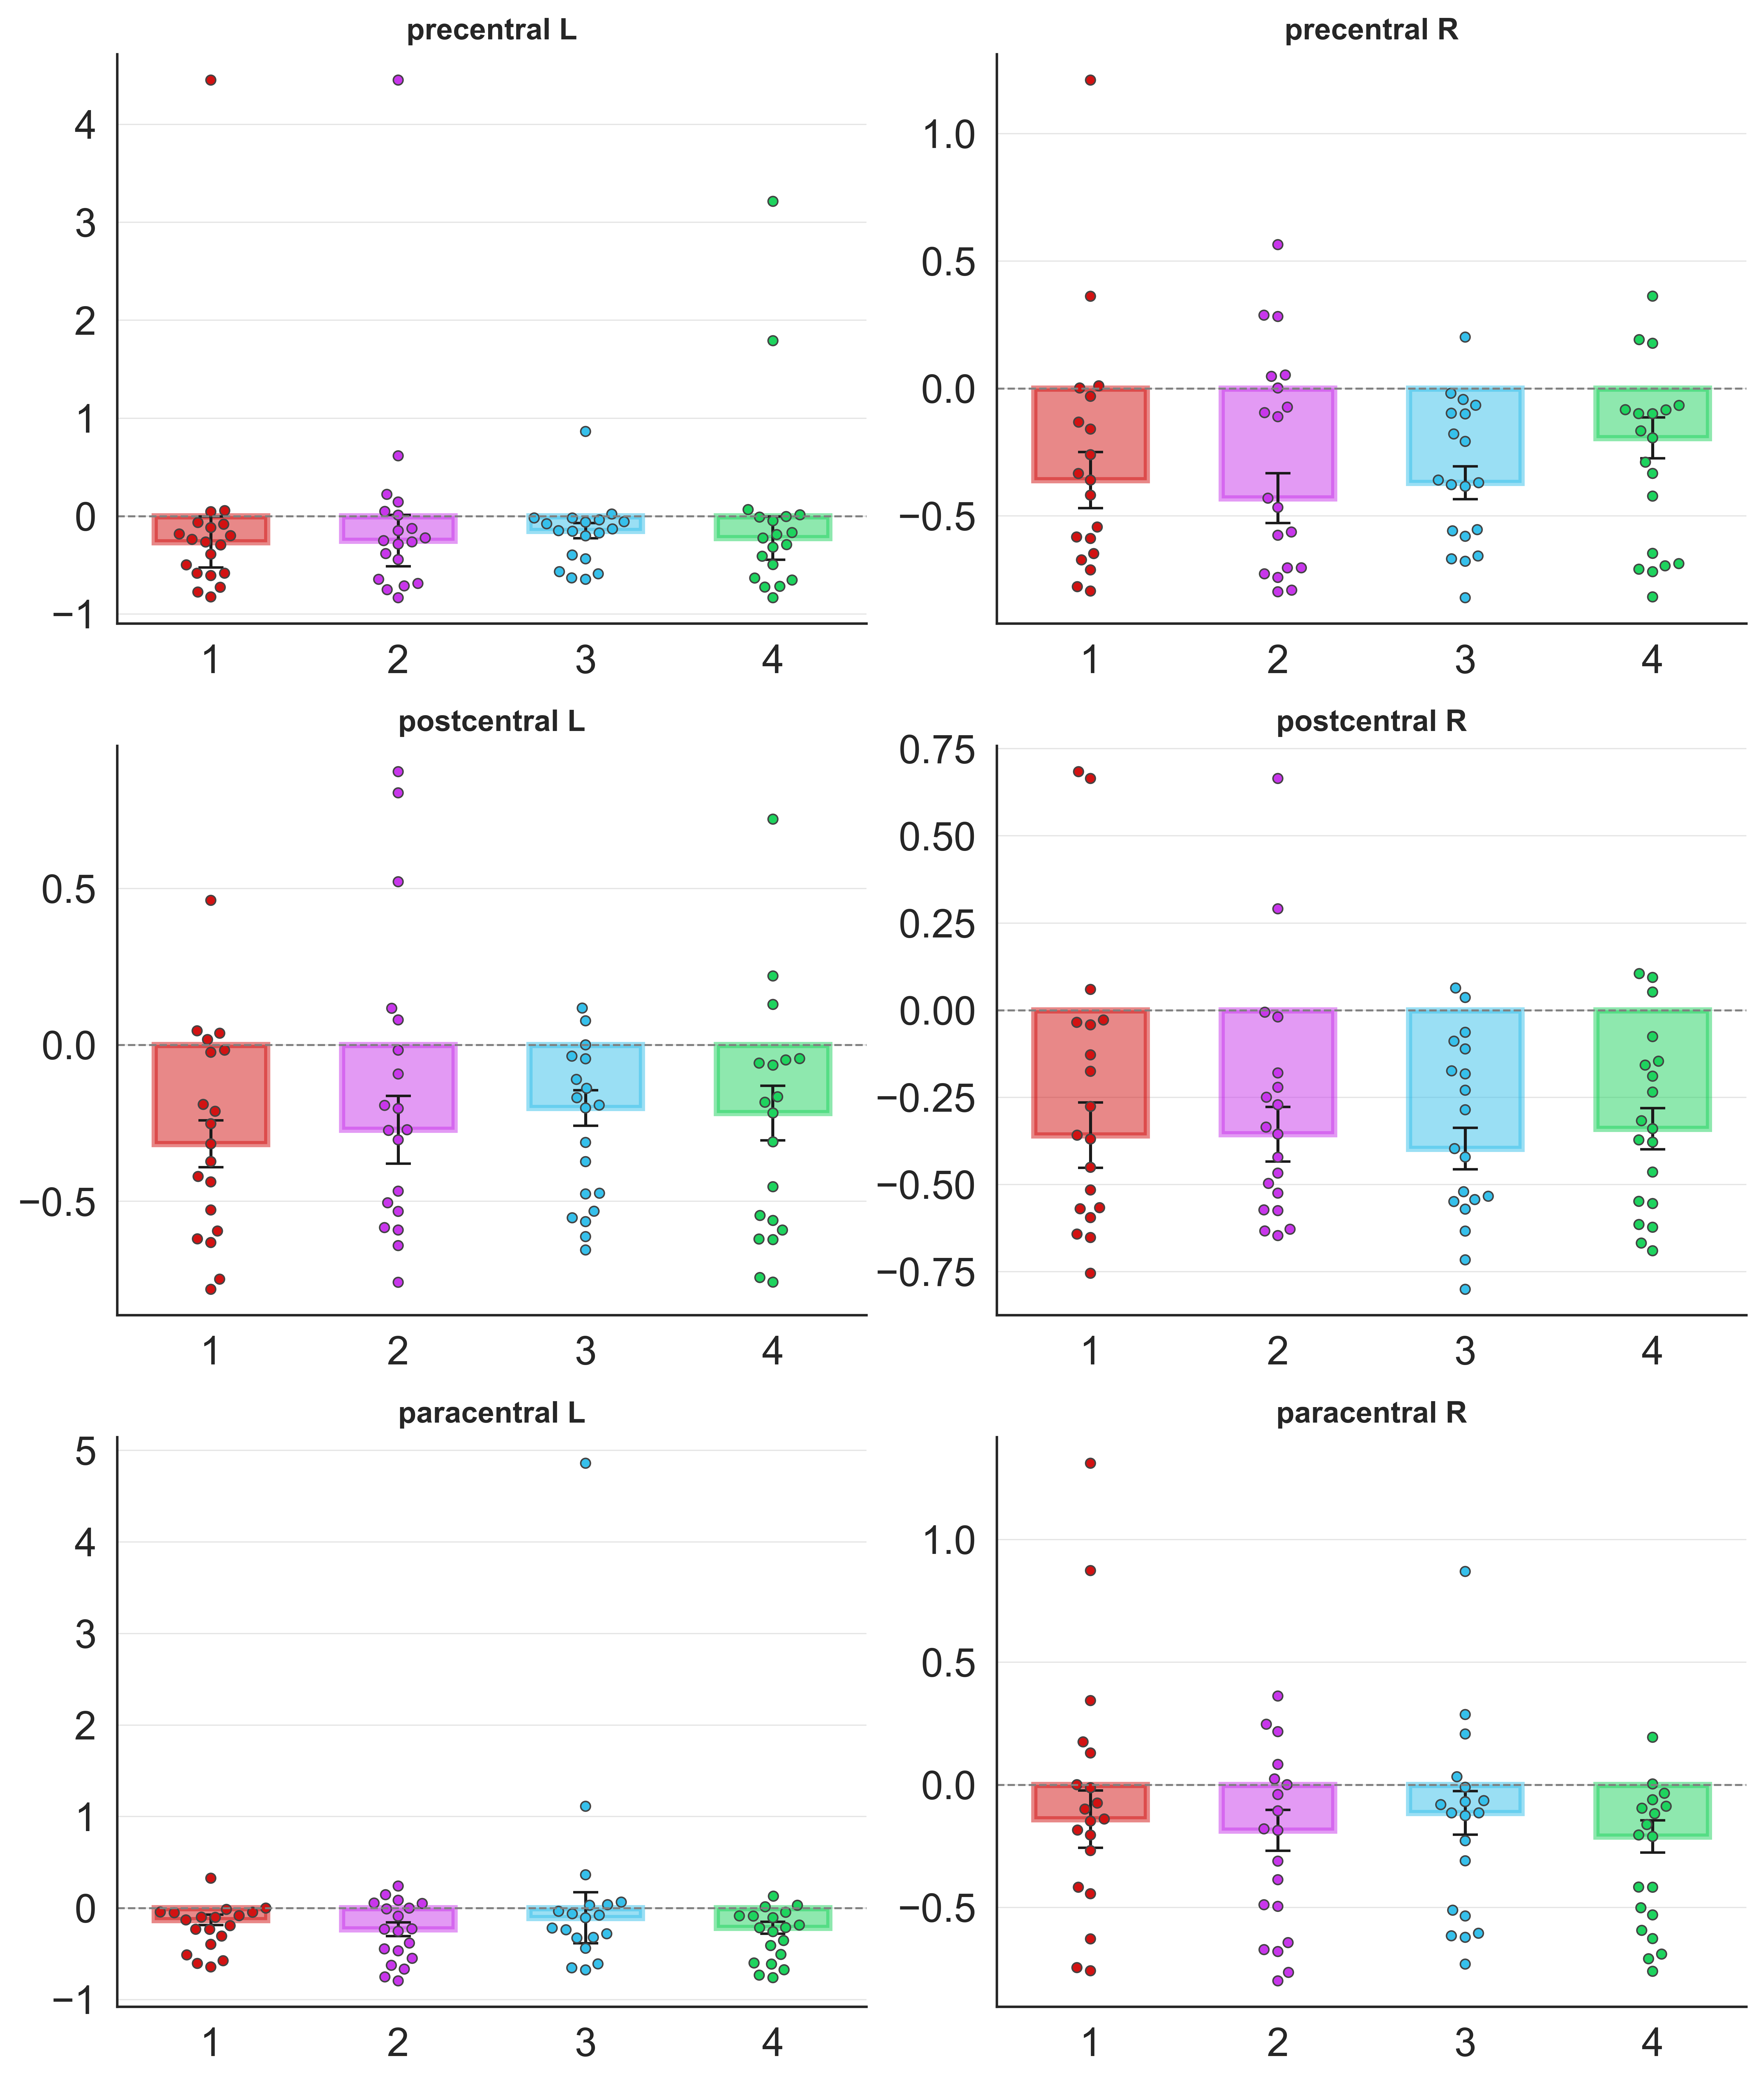

In [18]:
from scipy.stats import sem
target_roi = ['precentral L', 'precentral R', 'postcentral L', 'postcentral R',
              'paracentral L', 'paracentral R']

sessions = ["1", "2", "3", "4"]

# Define color palette
session_colors = {
    "1": "#D21212",  
    "2": "#C836EB",  
    "3": "#36C0EB", 
    "4": "#1ed35e"   
}

# Collect Data
data = {"ROI": [], "Session": [], "taue": []}
medians = []
sems = []

for roi in target_roi:
    idx = all_regions.index(roi)
    for s_idx, session in enumerate(sessions, 1):
        mi_vals = x_mi_all[s_idx][idx, 2, :]
        rs_vals = x_rest_all[s_idx][idx, 2, :]
        taue_vals = (mi_vals/rs_vals) - 1

        data["ROI"].extend([roi] * len(taue_vals))
        data["Session"].extend([session] * len(taue_vals))
        data["taue"].extend(taue_vals)

        # medians.append((np.median(mi_vals)/np.median(rs_vals)) - 1)
        medians.append(np.median(taue_vals))
        sems.append(sem(taue_vals))

df = pd.DataFrame(data)
summary_df = pd.DataFrame({
    "ROI": np.repeat(target_roi, len(sessions)),
    "Session": sessions * len(target_roi),
    "median": medians,
    "SEM": sems
})

sns.set_theme(style="white", context="paper", font_scale=1.2)
# edge_color = "#1F1B1B"

# cols, rows = 3, int(np.ceil(len(target_roi)/2))
cols, rows = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4), dpi=600)
axes = axes.flatten()

for i, roi in enumerate(target_roi):
    ax = axes[i]
    roi_df = df[df["ROI"] == roi]
    roi_summary = summary_df[summary_df["ROI"] == roi]

    # Barplot for each session manually to set individual colors
    for j, session in enumerate(sessions):
        session_median = roi_summary[roi_summary["Session"] == session]["median"].values[0]
        session_sem = roi_summary[roi_summary["Session"] == session]["SEM"].values[0]
        ax.bar(
            j, session_median,
            yerr=session_sem,
            capsize=5,
            color=session_colors[session],
            # edgecolor=edge_color,
            edgecolor=session_colors[session],
            linewidth=2.5,
            alpha=0.5,
            zorder=1,
            width=0.6
        )

    # Swarmplot — manually draw dots by session
    # for session in sessions:
    #     swarm_vals = roi_df[roi_df["Session"] == session]["taue"].values
    #     x_vals = [sessions.index(session)] * len(swarm_vals)
    #     ax.scatter(
    #         x_vals,
    #         swarm_vals,
    #         color=session_colors[session],
    #         # edgecolor='black',
    #         edgecolor=session_colors[session],
    #         linewidth=0.5,
    #         s=25,
    #         zorder=2
    #     )

    sns.swarmplot(
        data=roi_df,
        x="Session",
        y="taue",
        hue="Session",          
        ax=ax,
        size=3.9,                 
        palette=session_colors,
        # edgecolor=session_colors[session],
        linewidth=0.6,
        zorder=2
    )

    # Axis styling
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(roi, fontsize=12, weight='bold')
    # ax.set_xticks(range(len(sessions)))
    # ax.set_xticklabels(sessions)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='both', labelsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='-', linewidth=0.5, alpha=0.5)
    # ax.set_ylim([-0.9, 1.2])
    # ax.set_ylim([df['taue'].min(), df['taue'].max()])
    ax.legend().set_visible(False)

# Remove empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Super title
# plt.suptitle("taue(MI/RS-1) evolution across sessions in Motor ROIs", fontsize=15, weight='bold', y=1.03)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig(f"/Users/apurbadebnath/Desktop/taue_motor_evolution_mi_rs_meg2.png", dpi=600)
plt.show()
